# Data Preprocessing Diagnostic

This notebook performs a pre-cleaning diagnostic on the `Astram Event Data Anonymized.csv` dataset, checking for null percentages, duplicates, categorical inconsistencies, timestamp sanity, and missingness over time.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Astram_Event_Data_Anonymized.csv', low_memory=False)
df.head()

,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


## 1. Null Percentage Per Column

Checking the percentage of missing values in each column. We will specifically look at `map_file`, `comment`, `meta_data`, `route_path`, `direction`, `resolved_at_address`, `resolved_at_latitude`, `resolved_at_longitude`, `assigned_to_police_id`, and `citizen_accident_id`.

In [3]:
null_percentages = df.isnull().mean() * 100
null_percentages_sorted = null_percentages.sort_values(ascending=False)
print("Null Percentages (%):\n")
print(null_percentages_sorted[null_percentages_sorted > 0])

# Columns to potentially drop (e.g. > 97% null)
cols_to_drop = null_percentages_sorted[null_percentages_sorted > 97].index.tolist()
print("\nRecommendation: Consider dropping or keeping as sparse flags for the following columns (>97% missing):\n", cols_to_drop)

Null Percentages (%):

meta_data                100.000000
comment                  100.000000
map_file                 100.000000
direction                 99.473877
resolved_at_longitude     99.094580
resolved_at_latitude      99.094580
resolved_at_address       99.094580
resolved_by_id            99.094580
resolved_datetime         99.094580
citizen_accident_id       98.433868
assigned_to_police_id     98.433868
route_path                98.323749
cargo_material            96.623027
age_of_truck              96.623027
reason_breakdown          96.623027
end_datetime              94.004649
end_address               91.594274
junction                  69.289123
closed_by_id              61.568579
closed_datetime           61.568579
zone                      57.861250
gba_identifier            57.861250
veh_no                    40.217790
veh_type                  40.205555
description               16.640157
kgid                       3.168971
endlongitude               2.067784
endla

## 2. Duplicate IDs and Near-Duplicate Events

Check for exact duplicate `id` values, and check for near-duplicates (same location and cause within 5 minutes of each other).

In [4]:
print("Number of duplicate IDs:", df['id'].duplicated().sum())

# Ensure timestamps are datetime objects
df['start_datetime'] = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')

# Sort by location and time to find near-duplicates
df_sorted = df.sort_values(by=['latitude', 'longitude', 'event_cause', 'start_datetime']).copy()

# Calculate time difference between consecutive events at the same location with the same cause
df_sorted['time_diff'] = df_sorted.groupby(['latitude', 'longitude', 'event_cause'])['start_datetime'].diff()

# Count cases where time difference is less than or equal to 5 minutes
near_duplicates = df_sorted[df_sorted['time_diff'] <= pd.Timedelta(minutes=5)]
print(f"\nNumber of near-duplicate events (same location & cause within 5 mins): {len(near_duplicates)}")
display(near_duplicates[['id', 'latitude', 'longitude', 'event_cause', 'start_datetime', 'time_diff']].head())

Number of duplicate IDs: 0

Number of near-duplicate events (same location & cause within 5 mins): 105


,id,latitude,longitude,event_cause,start_datetime,time_diff
5308,FKID005308,12.855107,77.588708,pot_holes,2023-12-15 22:28:54.045000+00:00,0 days 00:00:27.918000
5316,FKID005316,12.866278,77.591888,pot_holes,2023-12-15 22:49:09.845000+00:00,0 days 00:01:03.877000
4462,FKID004462,12.890304,77.482790,accident,2023-11-12 10:00:46.584000+00:00,0 days 00:00:00
4464,FKID004464,12.890304,77.482790,accident,2023-11-12 10:00:46.584000+00:00,0 days 00:00:00
5056,FKID005056,12.898535,77.544467,pot_holes,2023-12-15 22:52:27.544000+00:00,0 days 00:00:34.829000


## 3. Categorical Spelling/Casing Inconsistencies

Checking for casing issues and inconsistencies in the `event_cause` column (e.g., 'Debris' vs 'debris', 'Fog / Low Visibility').

In [5]:
print("Unique Event Causes:\n")
print(df['event_cause'].value_counts(dropna=False))

# Observation: We may need to standardize the values, like `df['event_cause'] = df['event_cause'].str.lower()`
print("\nAfter standardizing (lowercase):\n")
print(df['event_cause'].str.lower().value_counts(dropna=False))

Unique Event Causes:

event_cause
vehicle_breakdown       4896
others                   638
pot_holes                537
construction             480
water_logging            458
accident                 365
tree_fall                284
road_conditions          170
congestion               136
public_event              84
procession                72
vip_movement              20
protest                   15
Debris                    12
test_demo                  3
Fog / Low Visibility       2
debris                     1
Name: count, dtype: int64

After standardizing (lowercase):

event_cause
vehicle_breakdown       4896
others                   638
pot_holes                537
construction             480
water_logging            458
accident                 365
tree_fall                284
road_conditions          170
congestion               136
public_event              84
procession                72
vip_movement              20
protest                   15
debris                 

## 4. Timestamp Sanity

Check if timestamps are in UTC and look for negative durations (e.g., `closed_datetime` before `start_datetime`).

In [6]:
# Convert datetime columns to UTC datetime
df['closed_datetime'] = pd.to_datetime(df['closed_datetime'], utc=True, errors='coerce')

print("Start Datetime Timezone:", df['start_datetime'].dt.tz)
print("Closed Datetime Timezone:", df['closed_datetime'].dt.tz)

# Check for negative durations
negative_durations = df[df['closed_datetime'] < df['start_datetime']]
print(f"\nNumber of rows with closed_datetime before start_datetime: {len(negative_durations)}")
if len(negative_durations) > 0:
    display(negative_durations[['id', 'start_datetime', 'closed_datetime']].head())

Start Datetime Timezone: UTC
Closed Datetime Timezone: UTC

Number of rows with closed_datetime before start_datetime: 3


,id,start_datetime,closed_datetime
1957,FKID001957,2024-02-25 05:38:30.045000+00:00,2024-02-25 05:37:44.948095+00:00
1966,FKID001966,2024-02-25 06:07:12.741000+00:00,2024-02-25 06:05:59.665142+00:00
5381,FKID005381,2023-12-20 00:45:55.392000+00:00,2023-12-19 02:05:45.656825+00:00


## 5. Missingness Over Time

Check if missingness in `zone` and `junction` fields is systematic over time (e.g., drops to 0% from February 2024 onward).

Percentage of populated 'zone' and 'junction' values over time:

                 zone   junction
year_month                      
2023-11     92.798354  62.757202
2023-12     92.726231  60.080183
2024-01     60.027663  55.947441
2024-02      0.000000   0.000000
2024-03      0.000000   0.000000
2024-04      0.000000   0.000000


/var/folders/2z/05ltm0pj7xnf51stplkmvbv40000gn/T/ipykernel_1035/3191663829.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['start_datetime'].dt.to_period('M')


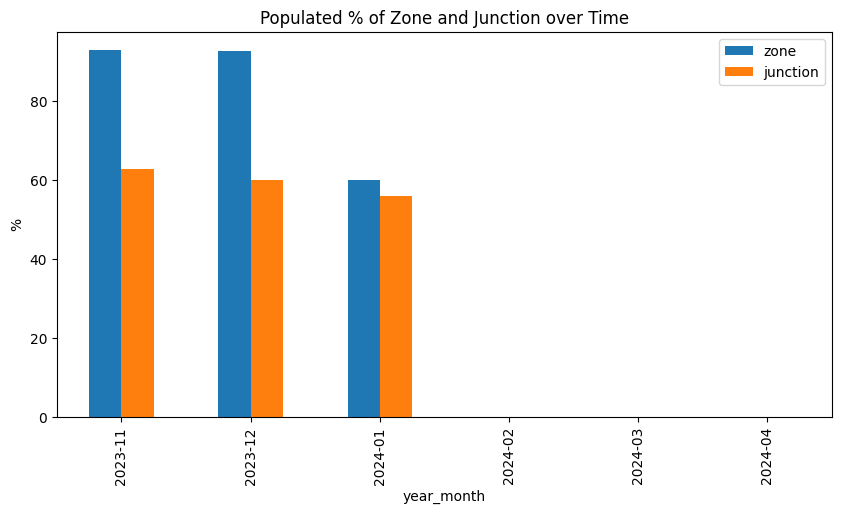

In [7]:
# Extract Year-Month for trend analysis
df['year_month'] = df['start_datetime'].dt.to_period('M')

# Calculate percentage of non-null values for 'zone' and 'junction' per month
monthly_completeness = df.groupby('year_month').agg({
    'zone': lambda x: x.notnull().mean() * 100,
    'junction': lambda x: x.notnull().mean() * 100
})

print("Percentage of populated 'zone' and 'junction' values over time:\n")
print(monthly_completeness)

# We can also plot this to visualize the drop
monthly_completeness.plot(kind='bar', figsize=(10, 5), title="Populated % of Zone and Junction over Time", ylabel="%")
plt.show()

## 6. Drop Empty Columns and Flag High Missingness
Dropping `map_file`, `comment`, `meta_data` and adding missingness flags for columns with >95% missing values.

In [8]:
# Task 1: Drop fully empty columns & flag >95% missing
fully_empty = ['map_file', 'comment', 'meta_data']
df.drop(columns=fully_empty, inplace=True, errors='ignore')

# Identify columns with > 95% missing values
missing_pct = df.isnull().mean() * 100
high_missing_cols = missing_pct[missing_pct > 95].index.tolist()

print(f"Columns with >95% missing values: {high_missing_cols}")

# Convert highly missing columns into sparse boolean flags (1 if present, 0 if null)
for col in high_missing_cols:
    df[f"{col}_flag"] = df[col].notnull().astype(int)

# Optional: drop the original highly missing columns after flagging, except vehicle specific ones we keep
cols_to_drop = [c for c in high_missing_cols if c not in ['veh_type', 'cargo_material', 'age_of_truck', 'route_path', 'direction', 'resolved_datetime', 'end_datetime']]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
df.head()

Columns with >95% missing values: ['direction', 'cargo_material', 'reason_breakdown', 'age_of_truck', 'route_path', 'assigned_to_police_id', 'citizen_accident_id', 'resolved_at_address', 'resolved_at_latitude', 'resolved_at_longitude', 'resolved_by_id', 'resolved_datetime']


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,reason_breakdown_flag,age_of_truck_flag,route_path_flag,assigned_to_police_id_flag,citizen_accident_id_flag,resolved_at_address_flag,resolved_at_latitude_flag,resolved_at_longitude_flag,resolved_by_id_flag,resolved_datetime_flag
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,0,0,0,0,0,0,0,0,0,0
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,0,0,0,0,0,1,1,1,1,1
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,0,0,0,0,0,0,0,0,0,0
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,0,0,0,0,0,0,0,0,0,0
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,0,0,0,0,0,0,0,0,0,0


## 7. Standardize Categorical Text
Lowercase, strip whitespace, and collapse rare event causes into an 'other' bucket.

In [9]:
# Task 2: Standardize event_cause
df['event_cause'] = df['event_cause'].astype(str).str.lower().str.strip()

# Check frequencies
cause_counts = df['event_cause'].value_counts()
print("Cause counts before collapsing:")
print(cause_counts)

# Collapse rare one-off causes into 'other' (e.g. less than 10 records)
rare_causes = cause_counts[cause_counts < 10].index
df['event_cause'] = df['event_cause'].apply(lambda x: 'other' if x in rare_causes else x)

print("\nCause counts after collapsing:")
print(df['event_cause'].value_counts())

Cause counts before collapsing:
event_cause
vehicle_breakdown       4896
others                   638
pot_holes                537
construction             480
water_logging            458
accident                 365
tree_fall                284
road_conditions          170
congestion               136
public_event              84
procession                72
vip_movement              20
protest                   15
debris                    13
test_demo                  3
fog / low visibility       2
Name: count, dtype: int64

Cause counts after collapsing:
event_cause
vehicle_breakdown    4896
others                638
pot_holes             537
construction          480
water_logging         458
accident              365
tree_fall             284
road_conditions       170
congestion            136
public_event           84
procession             72
vip_movement           20
protest                15
debris                 13
other                   5
Name: count, dtype: int64


## 8. Datetime to IST and Negative Duration Fix
Convert all datetime columns to Asia/Kolkata (IST), recompute durations, and flag data errors.

In [10]:
# Task 3: Convert to IST and compute duration
datetime_cols = ['start_datetime', 'end_datetime', 'modified_datetime', 'created_date', 'closed_datetime', 'resolved_datetime']

for col in datetime_cols:
    # Convert to datetime, coerce errors, set UTC then convert to IST
    df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)
    df[col] = df[col].dt.tz_convert('Asia/Kolkata')

# Compute duration in minutes
# For planned events or missing closed_datetime, fallback to resolved_datetime or end_datetime
fallback_end_time = df['closed_datetime'].fillna(df['resolved_datetime']).fillna(df['end_datetime'])
df['duration_mins'] = (fallback_end_time - df['start_datetime']).dt.total_seconds() / 60

# Null out or flag negative durations
negative_duration_mask = df['duration_mins'] < 0
print(f"Flagging {negative_duration_mask.sum()} negative duration records as data errors.")

df['is_data_error'] = 0
df.loc[negative_duration_mask, 'is_data_error'] = 1
df.loc[negative_duration_mask, 'duration_mins'] = np.nan

Flagging 50 negative duration records as data errors.


## 9. Cap and Log-Transform Outliers
Cap normal duration outliers, and isolate long-running infrastructure issues (like potholes/construction).

In [11]:
# Task 4: Handle long-running duration outliers

# Potholes and road_conditions often take weeks/months.
# Let's create a separate bucket for these long-running infrastructure issues.
# Treat any event taking > 24 hours (1440 mins) as a long-running outlier regardless of cause
long_running_mask = (df['duration_mins'] > 24*60)

df['is_long_infra_issue'] = 0
df.loc[long_running_mask, 'is_long_infra_issue'] = 1

# Cap extreme values at 99th percentile for non-infra issues
cap_value = df.loc[~long_running_mask, 'duration_mins'].quantile(0.99)
df['duration_mins_capped'] = df['duration_mins'].clip(upper=cap_value)

# Log transform the capped duration!
df['duration_mins_log'] = np.log1p(df['duration_mins_capped'])

print(f"Capped normal duration at {cap_value:.2f} mins.")

Capped normal duration at 1321.55 mins.


## 10. Resolve Near-Duplicate Events
Link near-duplicate events identified previously.

In [12]:
# Task 5: Resolve near-duplicates
df['lat_round'] = df['latitude'].round(3)
df['lon_round'] = df['longitude'].round(3)

df.sort_values(by=['lat_round', 'lon_round', 'event_cause', 'start_datetime'], inplace=True)

# Calculate time difference
df['time_diff'] = df.groupby(['lat_round', 'lon_round', 'event_cause'])['start_datetime'].diff()

# Mark as linked if within 5 minutes
df['is_linked_duplicate'] = (df['time_diff'] <= pd.Timedelta(minutes=5)).astype(int)

# Create a cluster ID for these linked events
new_cluster = (df['time_diff'] > pd.Timedelta(minutes=5)) | df['time_diff'].isna()
df['event_cluster_id'] = new_cluster.cumsum()

print(f"Found {df['is_linked_duplicate'].sum()} linked duplicate records.")

Found 441 linked duplicate records.


## 11. Impute Missing Zone Data
Backfilling `zone` using `police_station` or `corridor` fields as lookups since `zone` data drops entirely after Jan 2024.

In [13]:
# Task 6: Impute `zone` using `police_station` or `corridor` lookup
print("Missing zones before imputation:", df['zone'].isnull().sum())

valid_zones = df.dropna(subset=['zone'])
station_zone_map = valid_zones.groupby('police_station')['zone'].agg(lambda x: x.mode()[0] if not x.empty else np.nan).to_dict()
corridor_zone_map = valid_zones.groupby('corridor')['zone'].agg(lambda x: x.mode()[0] if not x.empty else np.nan).to_dict()

def impute_zone(row):
    if pd.notnull(row['zone']):
        return row['zone']
    if pd.notnull(row['police_station']) and row['police_station'] in station_zone_map:
        return station_zone_map[row['police_station']]
    if pd.notnull(row['corridor']) and row['corridor'] in corridor_zone_map:
        return corridor_zone_map[row['corridor']]
    return np.nan

df['zone_imputed'] = df.apply(impute_zone, axis=1)
print("Missing zones after imputation:", df['zone_imputed'].isnull().sum())

df['zone'] = df['zone_imputed']
df.drop(columns=['zone_imputed'], inplace=True)

Missing zones before imputation: 4729
Missing zones after imputation: 0


## 12. Vehicle Field Missingness Flags
Leave vehicle fields sparse but add missingness indicators.

In [14]:
# Task 7: Vehicle-specific fields missingness indicators
vehicle_fields = ['veh_type', 'cargo_material', 'age_of_truck']

for field in vehicle_fields:
    if field in df.columns:
        df[f'{field}_is_missing'] = df[field].isnull().astype(int)
        print(f"Created flag for {field}. Missing count: {df[field].isnull().sum()}")

df.head()

Created flag for veh_type. Missing count: 3286
Created flag for cargo_material. Missing count: 7897
Created flag for age_of_truck. Missing count: 7897


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,duration_mins_capped,duration_mins_log,lat_round,lon_round,time_diff,is_linked_duplicate,event_cluster_id,veh_type_is_missing,cargo_material_is_missing,age_of_truck_is_missing
4131,FKID004131,unplanned,12.801160,77.712216,0.0,0.0,"TCP Layout Main Road, Old Chandapura, Chandapu...",NaN,construction,False,...,NaN,NaN,12.801,77.712,NaT,0,1,1,1,1
4630,FKID004630,unplanned,12.801041,77.712123,0.0,0.0,"TCP Layout Main Road, Terracon Doctors Enclave...",NaN,construction,False,...,NaN,NaN,12.801,77.712,0 days 00:04:08.325000,1,1,1,1,1
1927,FKID001927,unplanned,12.802094,77.709193,0.0,0.0,"Hosur Road, Chandapura, Bengaluru, Karnataka. ...",NaN,vehicle_breakdown,False,...,NaN,NaN,12.802,77.709,NaT,0,2,0,1,1
1926,FKID001926,unplanned,12.801698,77.710295,0.0,0.0,"Hosur Road, Chandapura, Bengaluru, Karnataka. ...",NaN,vehicle_breakdown,False,...,NaN,NaN,12.802,77.710,NaT,0,3,0,1,1
4631,FKID004631,unplanned,12.801559,77.712131,0.0,0.0,"Hosur Road, Old Chandapura, Chandapura, Bengal...",NaN,construction,False,...,NaN,NaN,12.802,77.712,NaT,0,4,1,1,1


## 13. EDA Post-Cleaning: Category Distributions
Re-run distributions on the cleaned dataset for `event_cause`, `priority`, and `corridor` to verify skew reduction.

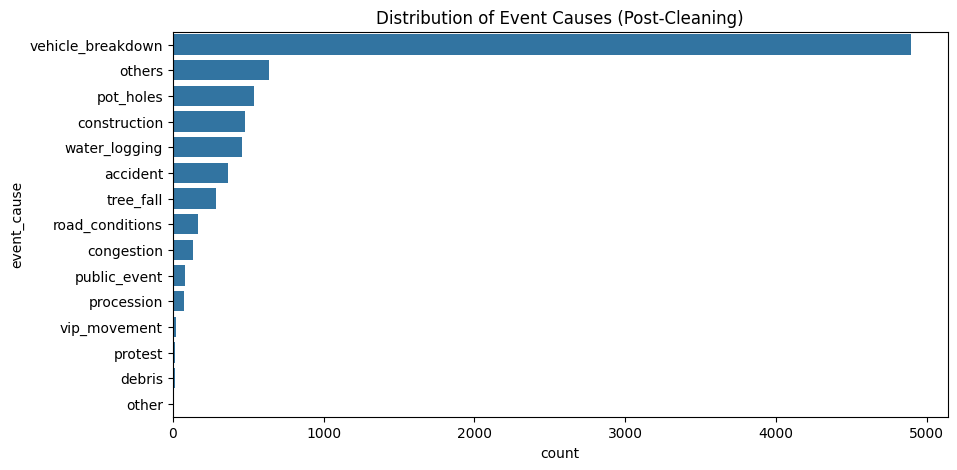

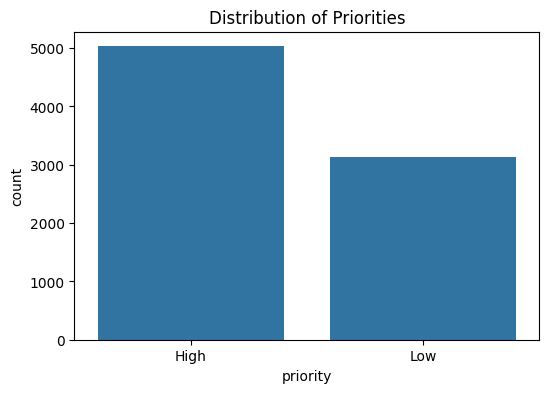

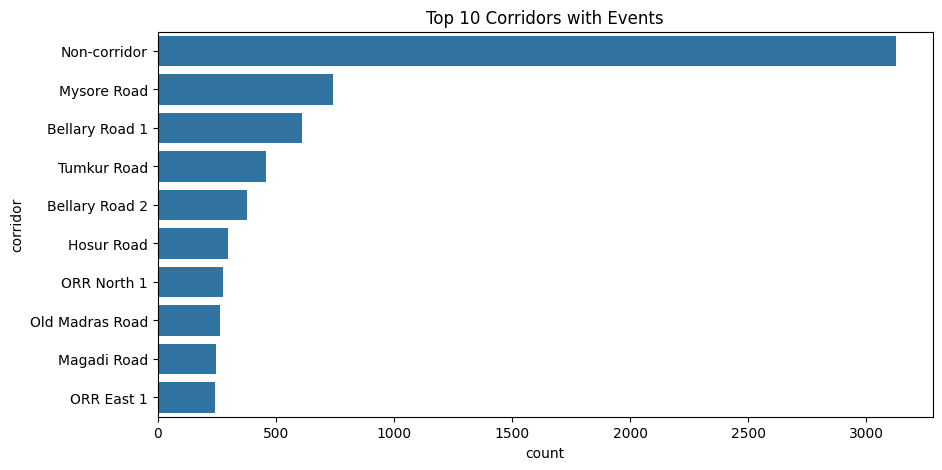

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Event cause distribution
plt.figure(figsize=(10, 5))
sns.countplot(y=df['event_cause'], order=df['event_cause'].value_counts().index)
plt.title('Distribution of Event Causes (Post-Cleaning)')
plt.show()

# Priority distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df['priority'], order=df['priority'].value_counts().index)
plt.title('Distribution of Priorities')
plt.show()

# Corridor distribution (Top 10)
plt.figure(figsize=(10, 5))
sns.countplot(y=df['corridor'], order=df['corridor'].value_counts().iloc[:10].index)
plt.title('Top 10 Corridors with Events')
plt.show()

## 14. Duration Distribution by Event Cause
Checking the duration distributions (using the capped duration column) across different event causes to ensure the target remains learnable and discriminative.

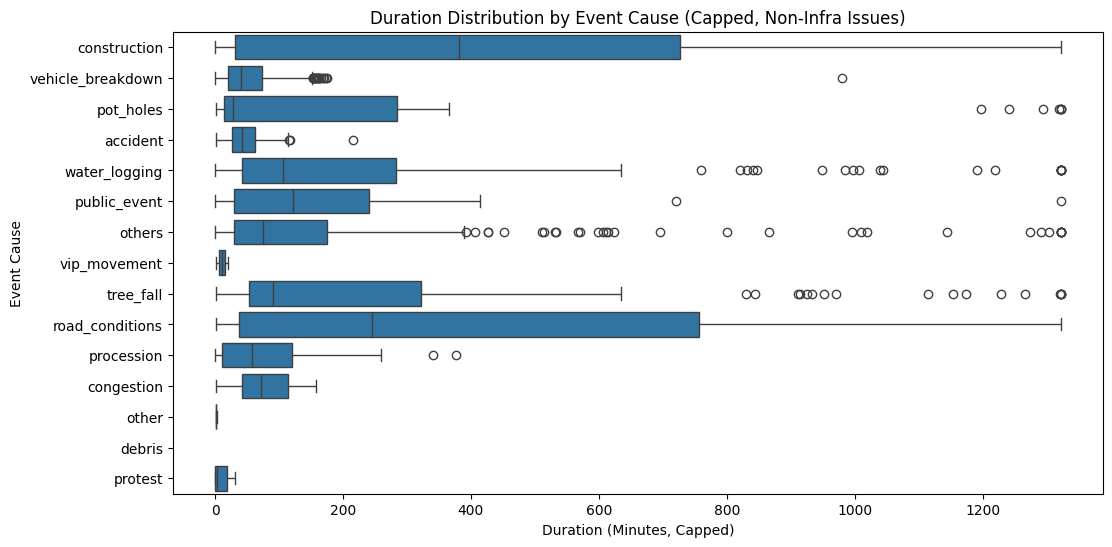

Median Duration by Event Cause (mins):
event_cause
construction         381.049185
road_conditions      245.916607
public_event         121.157483
water_logging        106.873632
tree_fall             90.368181
others                75.072531
congestion            71.535313
procession            58.202840
accident              41.372713
vehicle_breakdown     41.053556
pot_holes             27.686433
vip_movement          11.090042
protest                2.677833
other                  1.823843
debris                      NaN
Name: duration_mins_capped, dtype: float64


In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='duration_mins_capped', y='event_cause', data=df[df['is_long_infra_issue'] == 0])
plt.title('Duration Distribution by Event Cause (Capped, Non-Infra Issues)')
plt.xlabel('Duration (Minutes, Capped)')
plt.ylabel('Event Cause')
plt.show()

# Print median durations by cause
print('Median Duration by Event Cause (mins):')
print(df[df['is_long_infra_issue'] == 0].groupby('event_cause')['duration_mins_capped'].median().sort_values(ascending=False))

## 15. Time-of-Day and Day-of-Week Patterns
Extracting hour and day-of-week from the IST timestamps to observe temporal patterns.

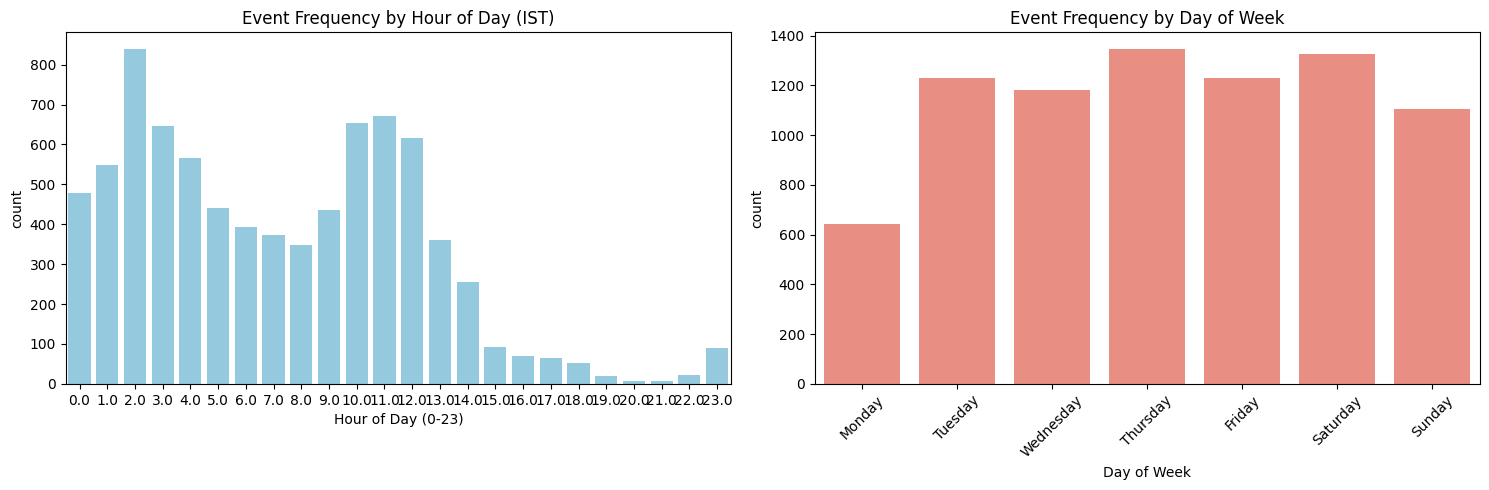

In [17]:
# Extract hour and day of week from IST start_datetime
df['start_hour'] = df['start_datetime'].dt.hour
df['start_dayofweek'] = df['start_datetime'].dt.dayofweek
df['start_day_name'] = df['start_datetime'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(x='start_hour', data=df, ax=axes[0], color='skyblue')
axes[0].set_title('Event Frequency by Hour of Day (IST)')
axes[0].set_xlabel('Hour of Day (0-23)')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='start_day_name', data=df, ax=axes[1], order=day_order, color='salmon')
axes[1].set_title('Event Frequency by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 16. Event Density by Corridor and Junction
Identifying hotspots based on corridors and junctions.

/var/folders/2z/05ltm0pj7xnf51stplkmvbv40000gn/T/ipykernel_1035/17995047.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_junctions.index, x=top_junctions.values, ax=axes[0], palette='viridis')


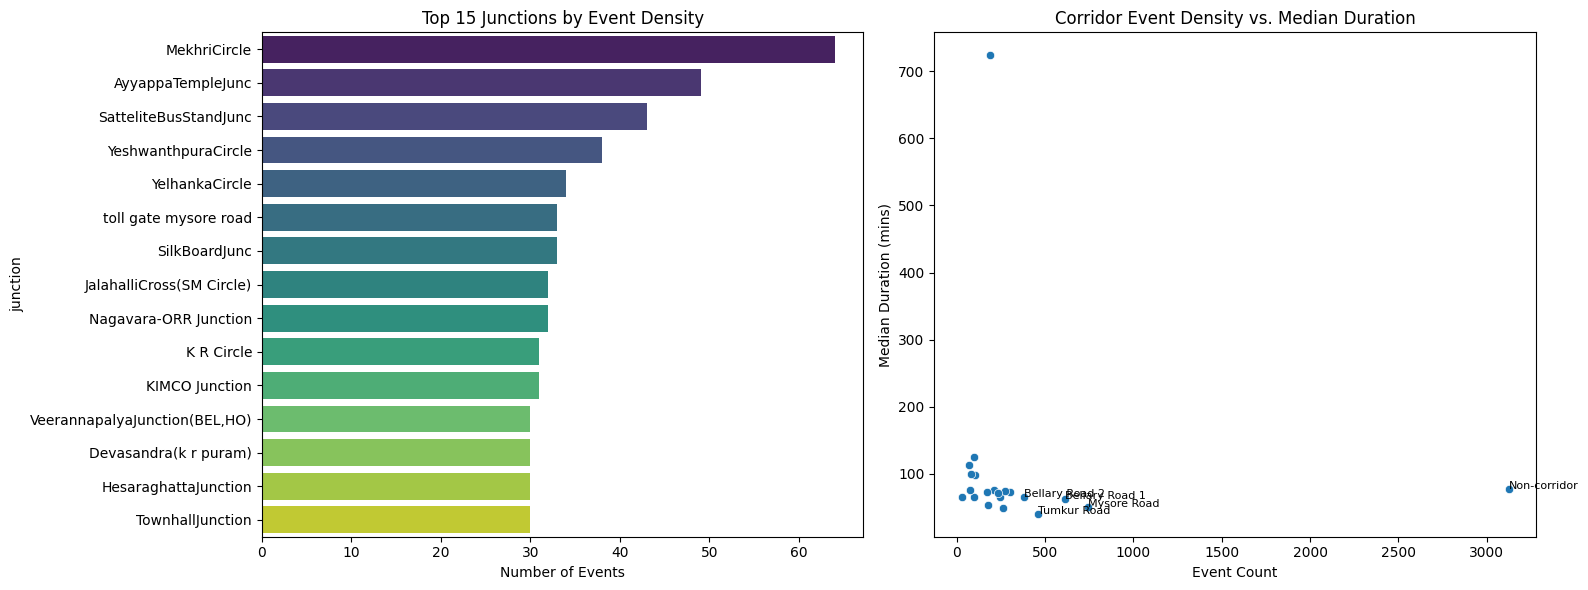

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 Junctions
top_junctions = df['junction'].value_counts().nlargest(15)
sns.barplot(y=top_junctions.index, x=top_junctions.values, ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Junctions by Event Density')
axes[0].set_xlabel('Number of Events')

# Event Density by Corridor (count vs median duration)
corridor_stats = df.groupby('corridor').agg(event_count=('id', 'count'), median_duration=('duration_mins_capped', 'median'))
sns.scatterplot(x='event_count', y='median_duration', data=corridor_stats, ax=axes[1])
for i in range(corridor_stats.shape[0]):
    # Annotate top corridors by volume
    if corridor_stats['event_count'].iloc[i] > corridor_stats['event_count'].quantile(0.8):
        axes[1].text(corridor_stats['event_count'].iloc[i], corridor_stats['median_duration'].iloc[i], corridor_stats.index[i], fontsize=8)
axes[1].set_title('Corridor Event Density vs. Median Duration')
axes[1].set_xlabel('Event Count')
axes[1].set_ylabel('Median Duration (mins)')
plt.tight_layout()
plt.show()

## 17. Severity Proxies: Closure and Priority vs. Duration
Cross-tabulating `requires_road_closure` and `priority` with duration to check their validity as severity markers.

Median Duration by Priority:
priority
High    65.083937
Low     77.072477
Name: duration_mins_capped, dtype: float64

Median Duration by Requires Road Closure:
requires_road_closure
False     66.874549
True     107.313492
Name: duration_mins_capped, dtype: float64


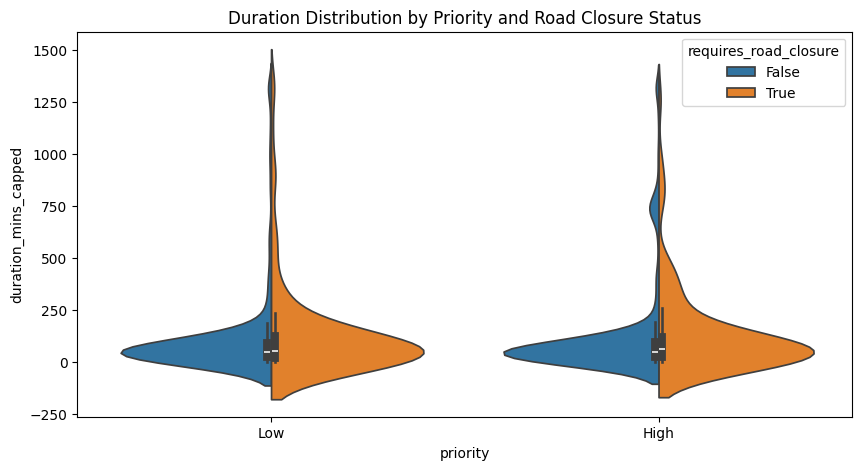

In [19]:
print("Median Duration by Priority:")
print(df.groupby('priority')['duration_mins_capped'].median())

print("\nMedian Duration by Requires Road Closure:")
print(df.groupby('requires_road_closure')['duration_mins_capped'].median())

plt.figure(figsize=(10, 5))
sns.violinplot(x='priority', y='duration_mins_capped', hue='requires_road_closure', data=df[df['is_long_infra_issue'] == 0], split=True)
plt.title('Duration Distribution by Priority and Road Closure Status')
plt.show()

## 18. Profiling Planned vs. Unplanned Events
Comparing the characteristics of planned (e.g. VIP movement, public events) versus unplanned (accidents, breakdowns) events.

Event Type Distribution:
event_type
unplanned    7706
planned       467
Name: count, dtype: int64


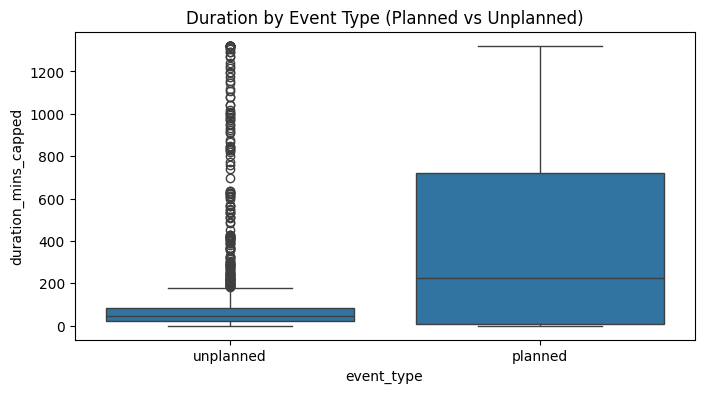


Top Causes for Planned Events:
event_cause
construction    311
public_event     84
procession       38
vip_movement     20
protest           8
Name: count, dtype: int64

Top Causes for Unplanned Events:
event_cause
vehicle_breakdown    4893
others                637
pot_holes             537
water_logging         458
accident              365
Name: count, dtype: int64


In [20]:
print("Event Type Distribution:")
print(df['event_type'].value_counts(dropna=False))

# Duration comparison
plt.figure(figsize=(8, 4))
sns.boxplot(x='event_type', y='duration_mins_capped', data=df[df['is_long_infra_issue'] == 0])
plt.title('Duration by Event Type (Planned vs Unplanned)')
plt.show()

# Cause distribution within Planned vs Unplanned
planned_causes = df[df['event_type'] == 'planned']['event_cause'].value_counts()
unplanned_causes = df[df['event_type'] == 'unplanned']['event_cause'].value_counts()

print("\nTop Causes for Planned Events:")
print(planned_causes.head())

print("\nTop Causes for Unplanned Events:")
print(unplanned_causes.head())

## 19. Feature Engineering: Event Identity
Creating a coarser cause-category grouping and ensuring `requires_road_closure` is a boolean flag.

In [21]:
# Coarser cause-category grouping
def group_cause(cause):
    if pd.isna(cause): return 'unknown'
    if cause in ['vehicle_breakdown', 'accident']: return 'incident'
    if cause in ['pot_holes', 'road_conditions', 'construction', 'water_logging', 'tree_fall']: return 'infrastructure'
    if cause in ['public_event', 'vip_movement', 'procession']: return 'planned_event'
    return 'other'

df['cause_category'] = df['event_cause'].apply(group_cause)
df['requires_road_closure'] = df['requires_road_closure'].fillna(False).astype(int)

print("Cause Category Distribution:")
print(df['cause_category'].value_counts())

Cause Category Distribution:
cause_category
incident          5261
infrastructure    1929
other              807
planned_event      176
Name: count, dtype: int64


## 20. Feature Engineering: Time Features
Cyclically encoding hour and day-of-week, creating a rush-hour flag, and calculating lead time for planned events.

In [22]:
import numpy as np
# Cyclical encoding for hour (0-23)
df['hour_sin'] = np.sin(2 * np.pi * df['start_hour']/24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['start_hour']/24.0)

# Cyclical encoding for day of week (0-6)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['start_dayofweek']/7.0)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['start_dayofweek']/7.0)

# Rush hour flag (e.g., 8-11 AM and 5-8 PM)
df['is_rush_hour'] = df['start_hour'].apply(lambda x: 1 if (8 <= x <= 11) or (17 <= x <= 20) else 0)

# Lead time for planned events (created_date to start_datetime)
# If unplanned, lead_time is NaN.
df['lead_time_mins'] = (df['start_datetime'] - df['created_date']).dt.total_seconds() / 60
# Flag events logged late (negative lead time)
df['logged_late_flag'] = np.where((df['event_type'] == 'planned') & (df['lead_time_mins'] < 0), 1, 0)
# Only apply to planned events and clip at 0
df['lead_time_mins'] = np.where(df['event_type'] == 'planned', df['lead_time_mins'].clip(lower=0), np.nan)

print("Rush Hour Events:\n", df['is_rush_hour'].value_counts())
print("\nAverage Lead Time for Planned Events (mins):", df[df['event_type'] == 'planned']['lead_time_mins'].mean())

Rush Hour Events:
 is_rush_hour
0    5918
1    2255
Name: count, dtype: int64

Average Lead Time for Planned Events (mins): 0.033180263652968035


## 21. Feature Engineering: Location Features
Calculating affected-stretch length using Haversine distance, and creating a recurring-location event count.

In [23]:
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    # Returns distance in km
    if pd.isna(lon1) or pd.isna(lat1) or pd.isna(lon2) or pd.isna(lat2) or (lon1==0 and lat1==0) or (lon2==0 and lat2==0):
        return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers
    return c * r

df['affected_stretch_km'] = df.apply(lambda row: haversine(row['longitude'], row['latitude'], row['endlongitude'], row['endlatitude']), axis=1)

# Recurring location event count (e.g. rounded lat/long or junction)
df['lat_round'] = df['latitude'].round(3)
df['lon_round'] = df['longitude'].round(3)
loc_counts = df.groupby(['lat_round', 'lon_round']).size().reset_index(name='recurring_loc_count')
df = pd.merge(df, loc_counts, on=['lat_round', 'lon_round'], how='left')

print("Affected stretch km missingness:", df['affected_stretch_km'].isna().sum(), "/", len(df))
print("Max recurring location count:", df['recurring_loc_count'].max())

Affected stretch km missingness: 7484 / 8173
Max recurring location count: 65


## 22. Feature Engineering: Historical Aggregates
Rolling event count and median duration per corridor-cause pair over the past 7 and 30 days.

In [24]:
# Sort by time for rolling window calculations
df_sorted_time = df.dropna(subset=['start_datetime']).sort_values(by=['corridor', 'event_cause', 'start_datetime']).set_index('start_datetime')

# Function to calculate rolling features
def calc_rolling_features(group):
    if len(group) == 0:
        return pd.DataFrame()
    group = group.copy()
    group['shifted_dur'] = group['duration_mins_capped'].shift(1)
    
    # 7-day rolling
    roll_7d = group.rolling('7D')
    count_7d = roll_7d['id'].count() - 1 # exclude current event
    med_7d = roll_7d['shifted_dur'].median()
    
    # 30-day rolling
    roll_30d = group.rolling('30D')
    count_30d = roll_30d['id'].count() - 1
    med_30d = roll_30d['shifted_dur'].median()
    
    return pd.DataFrame({
        'id': group['id'],
        'roll_7d_count': count_7d,
        'roll_7d_median_dur': med_7d,
        'roll_30d_count': count_30d,
        'roll_30d_median_dur': med_30d
    })

# Note: Using reset_index with include_groups=False for pandas 2.2+
try:
    rolling_feats = df_sorted_time.groupby(['corridor', 'event_cause'], group_keys=False).apply(calc_rolling_features, include_groups=False).reset_index(drop=True)
except TypeError:
    rolling_feats = df_sorted_time.groupby(['corridor', 'event_cause']).apply(calc_rolling_features).reset_index(drop=True)

df = pd.merge(df, rolling_feats, on='id', how='left')

print("Sample of rolling features:")
display(df[['corridor', 'event_cause', 'start_datetime', 'roll_7d_count', 'roll_30d_count']].head())

Sample of rolling features:


,corridor,event_cause,start_datetime,roll_7d_count,roll_30d_count
0,Non-corridor,construction,2023-11-18 13:04:39.257000+05:30,2.0,2.0
1,Non-corridor,construction,2023-11-18 13:08:47.582000+05:30,3.0,3.0
2,Non-corridor,vehicle_breakdown,2024-02-24 18:05:12.564000+05:30,83.0,284.0
3,Non-corridor,vehicle_breakdown,2024-02-24 18:06:34.672000+05:30,84.0,285.0
4,Non-corridor,construction,2023-11-18 13:10:01.440000+05:30,4.0,4.0


## 23. Feature Engineering: Text-Derived Features
Extracting description length, redaction-placeholder flags (`[LOCATION]`, `[PERSON]`, `[PHONE]`), and severity keywords.

In [25]:
df['description'] = df['description'].fillna('')
df['desc_length'] = df['description'].apply(len)

# Redaction flags
df['has_redacted_loc'] = df['description'].str.contains(r'\[LOCATION\]', regex=True).astype(int)
df['has_redacted_person'] = df['description'].str.contains(r'\[PERSON\]', regex=True).astype(int)
df['has_redacted_phone'] = df['description'].str.contains(r'\[PHONE\]', regex=True).astype(int)

# Severity keywords flag (e.g., severe, blocked, fatal, heavy, jammed)
severity_keywords = ['severe', 'blocked', 'fatal', 'heavy', 'jam', 'dead', 'massive', 'huge']
pattern = '|'.join(severity_keywords)
df['has_severity_keyword'] = df['description'].str.lower().str.contains(pattern, regex=True).astype(int)

print("Descriptions with redacted locs:", df['has_redacted_loc'].sum())
print("Descriptions with severity keywords:", df['has_severity_keyword'].sum())

Descriptions with redacted locs: 1359
Descriptions with severity keywords: 142


## 24. Target Variables
Defining the final targets: log-transformed capped duration and a combined severity label from priority and road-closure.

In [26]:
# Target 1: Cleaned/capped duration (log-transformed) was already created as `duration_mins_log`

# Target 2: Combined Severity Label
# Let's map priority to numeric: Low=1, Medium=2, High=3
priority_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['priority_num'] = df['priority'].map(priority_map).fillna(1) # Default to low if missing

# Severity label: Combine priority (1-3) and road closure (0-1)
# e.g. severity_score = priority_num + (2 if road_closure else 0)
df['severity_score'] = df['priority_num'] + (df['requires_road_closure'] * 2)

print("Severity Score Distribution:")
print(df['severity_score'].value_counts().sort_index())

df[['duration_mins_capped', 'duration_mins_log', 'severity_score']].head()

Severity Score Distribution:
severity_score
1.0    2764
3.0    5112
5.0     297
Name: count, dtype: int64


,duration_mins_capped,duration_mins_log,severity_score
0,NaN,NaN,1.0
1,NaN,NaN,1.0
2,NaN,NaN,1.0
3,NaN,NaN,1.0
4,NaN,NaN,1.0


In [27]:
print(df.head())
print(df.columns.tolist())

           id event_type   latitude  longitude  endlatitude  endlongitude  \
0  FKID004131  unplanned  12.801160  77.712216          0.0           0.0   
1  FKID004630  unplanned  12.801041  77.712123          0.0           0.0   
2  FKID001927  unplanned  12.802094  77.709193          0.0           0.0   
3  FKID001926  unplanned  12.801698  77.710295          0.0           0.0   
4  FKID004631  unplanned  12.801559  77.712131          0.0           0.0   

                                             address end_address  \
0  TCP Layout Main Road, Old Chandapura, Chandapu...         NaN   
1  TCP Layout Main Road, Terracon Doctors Enclave...         NaN   
2  Hosur Road, Chandapura, Bengaluru, Karnataka. ...         NaN   
3  Hosur Road, Chandapura, Bengaluru, Karnataka. ...         NaN   
4  Hosur Road, Old Chandapura, Chandapura, Bengal...         NaN   

         event_cause  requires_road_closure  ... roll_7d_median_dur  \
0       construction                      0  ...         

## 25. Investigate Negative Duration Rows
Analyzing the rows where `duration_mins` was negative before being nulled out.

In [28]:
negative_df = df[df['is_data_error'] == 1].copy()
print(f"Total negative duration rows: {len(negative_df)}")
print("Missingness in fallback fields for these rows:")
print(negative_df[['closed_datetime', 'resolved_datetime', 'end_datetime']].isnull().sum())

# Decision: Since these are only 50 rows (a tiny fraction of the dataset) and represent corrupted timestamp logic, we will drop them from the training set entirely rather than trying to impute a target.
df = df[df['is_data_error'] == 0].copy()
print(f"Dataset size after dropping negative duration errors: {df.shape[0]}")

Total negative duration rows: 50
Missingness in fallback fields for these rows:
closed_datetime      47
resolved_datetime    50
end_datetime          3
dtype: int64
Dataset size after dropping negative duration errors: 8123


## 25b. Diagnose Duration Target Missingness
Investigating which event_cause and status values contribute most to missing `duration_mins_log` before finalizing the modeling dataset.

In [29]:
print("=== Duration Target Missingness Analysis ===")
print(f"Rows with any duration (raw): {df['duration_mins'].notna().sum()} / {len(df)}")
print(f"Rows with duration_mins_log not null: {df['duration_mins_log'].notna().sum()} / {len(df)}\n")

# Check missingness by status
print("--- Missingness by Status ---")
print(df.groupby('status')['duration_mins_log'].apply(lambda x: x.isna().sum()).rename('missing_count'))
print()

# Check missingness by event_cause
print("--- Missingness by Event Cause (sorted worst first) ---")
miss_by_cause = df.groupby('event_cause')['duration_mins_log'].apply(
    lambda x: f"{x.isna().sum()}/{len(x)} ({100*x.isna().mean():.0f}% missing)"
).rename('missing')
miss_pct_by_cause = df.groupby('event_cause')['duration_mins_log'].apply(lambda x: x.isna().mean())
print(miss_by_cause.loc[miss_pct_by_cause.sort_values(ascending=False).index])
print()

# What are 'active' events? Are they a particular cause?
print("--- Active Event Breakdown by Cause ---")
active_df = df[df['status'] == 'active']
print(active_df['event_cause'].value_counts().head(10))
print()

# Check if fallback timestamps help
missing_dur = df[df['duration_mins'].isna()]
print("--- Timestamp Availability in Missing-Duration Rows ---")
for col in ['closed_datetime', 'resolved_datetime', 'end_datetime']:
    print(f"  {col}: {missing_dur[col].notna().sum()} / {len(missing_dur)} populated")

=== Duration Target Missingness Analysis ===
Rows with any duration (raw): 3498 / 8123
Rows with duration_mins_log not null: 3498 / 8123

--- Missingness by Status ---
status
active      1003
closed      3619
resolved       3
Name: missing_count, dtype: int64

--- Missingness by Event Cause (sorted worst first) ---
event_cause
congestion             114/136 (84% missing)
vip_movement             16/20 (80% missing)
accident               271/365 (74% missing)
debris                    9/13 (69% missing)
pot_holes              360/536 (67% missing)
vehicle_breakdown    3051/4893 (62% missing)
other                      3/5 (60% missing)
public_event             40/79 (51% missing)
procession               32/67 (48% missing)
protest                   7/15 (47% missing)
water_logging          213/458 (47% missing)
road_conditions         77/169 (46% missing)
tree_fall              108/283 (38% missing)
others                 217/637 (34% missing)
construction           107/447 (24% missi

## 26. Finalize the Feature Matrix
Encoding categoricals and dropping data-leakage columns to build the final modeling dataset.

In [30]:
# 1. One-hot encoding for low-cardinality fields
low_card_cols = ['cause_category', 'priority', 'event_type', 'requires_road_closure']
df_model = pd.get_dummies(df, columns=low_card_cols, drop_first=False)

# 2. Frequency encoding for high-cardinality fields
high_card_cols = ['corridor', 'zone', 'police_station']
for col in high_card_cols:
    freq_encoding = df_model[col].value_counts(normalize=True)
    df_model[f'{col}_freq'] = df_model[col].map(freq_encoding).fillna(0)
# Non-corridor is an absence label, not a real busy corridor — zero it out
df_model['corridor_freq'] = df_model.apply(
    lambda r: 0.0 if r['corridor'] == 'Non-corridor' else r['corridor_freq'], axis=1
)

# Assemble engineered features
feature_cols = [
    # Time
    'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_rush_hour', 'lead_time_mins', 'logged_late_flag',
    # Location
    'affected_stretch_km', 'recurring_loc_count',
    'corridor_freq', 'zone_freq', 'police_station_freq',
    # Historical
    'roll_7d_count', 'roll_7d_median_dur', 'roll_30d_count', 'roll_30d_median_dur',
    # Text-derived
    'desc_length', 'has_redacted_loc', 'has_redacted_person', 'has_redacted_phone', 'has_severity_keyword',
    # Vehicle missingness flags
    'veh_type_is_missing', 'cargo_material_is_missing', 'age_of_truck_is_missing',
    # Targets
    'duration_mins_log', 'severity_score',
    # Tracking columns
    'start_datetime', 'event_cause'
]

# Add the one-hot columns to our feature list
ohe_cols = [c for c in df_model.columns if any(c.startswith(orig + '_') for orig in low_card_cols)]
feature_cols.extend(ohe_cols)

# Ensure lead_time_mins has no NaNs (fill with 0 for unplanned events)
df_model['lead_time_mins'] = df_model['lead_time_mins'].fillna(0)
df_model['roll_7d_count'] = df_model['roll_7d_count'].fillna(0)
df_model['roll_30d_count'] = df_model['roll_30d_count'].fillna(0)
df_model['roll_7d_median_dur'] = df_model['roll_7d_median_dur'].fillna(df_model['duration_mins_capped'].median())
df_model['roll_30d_median_dur'] = df_model['roll_30d_median_dur'].fillna(df_model['duration_mins_capped'].median())
df_model['affected_stretch_km'] = df_model['affected_stretch_km'].fillna(0)

# cause_median_log will be added AFTER the train/val split (see cell 59),
# to avoid leaking validation-period durations into a training feature.
df_model['cause_median_log'] = np.nan
feature_cols.append('cause_median_log')

# Scope model to events with confirmed closure data ONLY
# Note: This is a deliberate, explicit scoping decision. We are training on confirmed-closure events,
# not trying to predict duration on events still active or never properly closed.
model_data = df_model[feature_cols].dropna(subset=['duration_mins_log', 'severity_score']).copy()

# Print breakdown of what was dropped
print(f"Original dataset: {len(df_model)} rows")
print(f"After scoping to confirmed-closure events: {len(model_data)} rows")
print(f"Retained event_cause distribution:")
print(model_data['event_cause'].value_counts())
print(f"\nduration_mins_log distribution (sanity check):")
print(model_data['duration_mins_log'].describe())
print(f"Final modeling dataset shape: {model_data.shape}")


Original dataset: 8123 rows
After scoping to confirmed-closure events: 3498 rows
Retained event_cause distribution:
event_cause
vehicle_breakdown    1842
others                420
construction          340
water_logging         245
pot_holes             176
tree_fall             175
accident               94
road_conditions        92
public_event           39
procession             35
congestion             22
protest                 8
vip_movement            4
debris                  4
other                   2
Name: count, dtype: int64

duration_mins_log distribution (sanity check):
count    3498.000000
mean        4.587343
std         1.771546
min         0.028150
25%         3.380739
50%         4.259816
75%         6.584485
max         7.187318
Name: duration_mins_log, dtype: float64
Final modeling dataset shape: (3498, 40)


In [31]:
print(df_model)
print(df)
print(model_data)

              id   latitude  longitude  endlatitude  endlongitude  \
0     FKID004131  12.801160  77.712216     0.000000      0.000000   
1     FKID004630  12.801041  77.712123     0.000000      0.000000   
2     FKID001927  12.802094  77.709193     0.000000      0.000000   
3     FKID001926  12.801698  77.710295     0.000000      0.000000   
4     FKID004631  12.801559  77.712131     0.000000      0.000000   
...          ...        ...        ...          ...           ...   
8168  FKID000056  13.264447  77.718763    13.264536     77.718785   
8169  FKID005825  13.264501  77.718793     0.000000      0.000000   
8170  FKID008136  13.267339  77.719425     0.000000      0.000000   
8171  FKID000079  13.267362  77.719589     0.000000      0.000000   
8172  FKID000434  13.267510  77.719871     0.000000      0.000000   

                                                address  \
0     TCP Layout Main Road, Old Chandapura, Chandapu...   
1     TCP Layout Main Road, Terracon Doctors Enclave.

## 27. Time-based Train/Validation Split
Splitting chronologically to respect the rolling features. Train: Nov 2023 - Feb 2024. Validate: Mar - Apr 2024.

In [32]:
train_mask = (model_data['start_datetime'] >= '2023-11-01') & (model_data['start_datetime'] < '2024-03-01')
val_mask = (model_data['start_datetime'] >= '2024-03-01') & (model_data['start_datetime'] < '2024-05-01')

train_df = model_data[train_mask].copy()
val_df = model_data[val_mask].copy()

# Compute cause_median_log on TRAIN ONLY, then map onto both sets — no validation leakage.
cause_median_map = train_df.groupby('event_cause')['duration_mins_log'].median()
global_median_train = train_df['duration_mins_log'].median()
# event_cause was dropped from feature_cols' final X, but is still in train_df/val_df at this point
train_df['cause_median_log'] = train_df['event_cause'].map(cause_median_map).fillna(global_median_train)
val_df['cause_median_log'] = val_df['event_cause'].map(cause_median_map).fillna(global_median_train)


print(f"Training set size: {train_df.shape[0]}")
print(f"Validation set size: {val_df.shape[0]}")

# Separate features and targets
drop_for_X = ['duration_mins_log', 'severity_score', 'start_datetime', 'event_cause']
X_train = train_df.drop(columns=drop_for_X)
y_train_duration = train_df['duration_mins_log']
y_train_severity = train_df['severity_score']

X_val = val_df.drop(columns=drop_for_X)
y_val_duration = val_df['duration_mins_log']
y_val_severity = val_df['severity_score']

Training set size: 2404
Validation set size: 1094


## 28. Baseline Modeling
Training LightGBM models for both duration (regression) and severity (classification) and inspecting feature importances.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1247
[LightGBM] [Info] Number of data points in the train set: 2404, number of used features: 34
[LightGBM] [Info] Start training from score 4.518382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

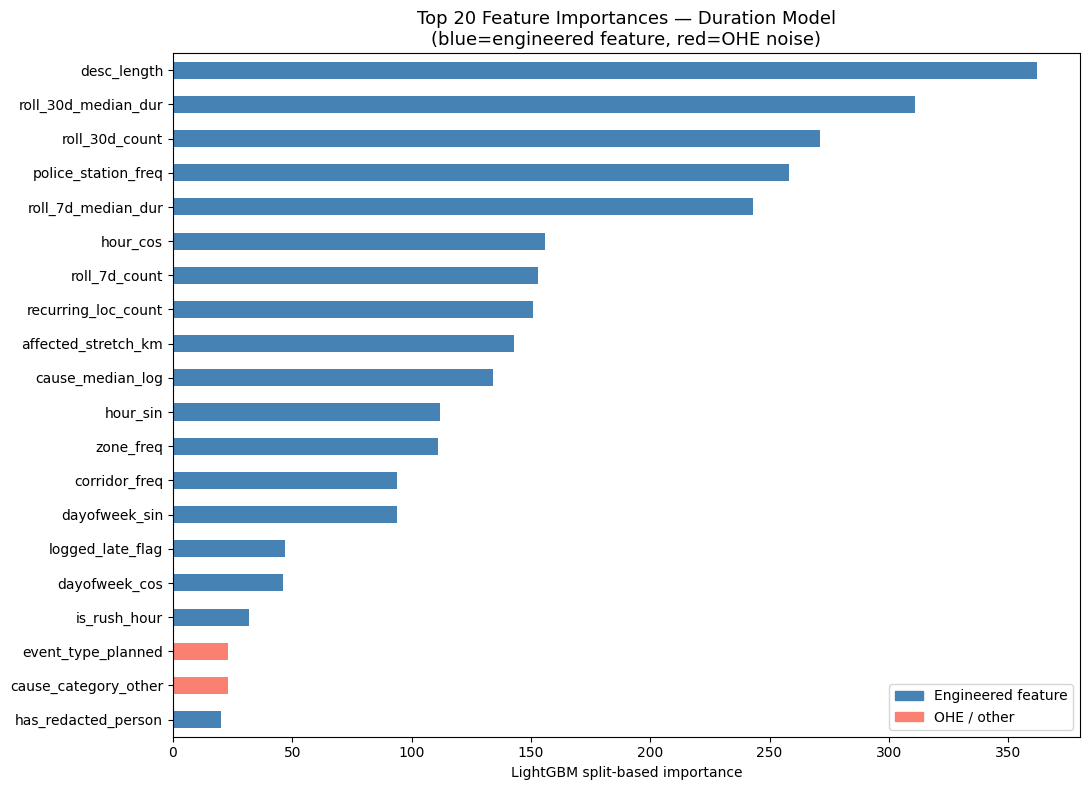


Engineered features account for 95.4% of total split importance.
Top 5 features by importance:
desc_length            362
roll_30d_median_dur    311
roll_30d_count         271
police_station_freq    258
roll_7d_median_dur     243
dtype: int32
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1236
[LightGBM] [Info] Number of data points in the train set: 2404, number of used features: 29
[LightGBM] [Info] Start training from score -1.126878
[LightGBM] [Info] Start training from score -0.451866
[LightGBM] [Info] Start training from score -3.231012
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

In [33]:
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Duration Model (Regression) ---
# Hybrid: cause_median_log is already in X_train as a feature.
# LightGBM will learn corridor/time/rolling corrections on top of that naive baseline.
lgb_reg = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=20,
    max_depth=5,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.5,
    random_state=42
)
lgb_reg.fit(X_train, y_train_duration)
dur_preds = lgb_reg.predict(X_val)

# Ridge for simpler model comparison
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_scaled, y_train_duration)
ridge_preds = ridge_reg.predict(X_val_scaled)

rmse = np.sqrt(mean_squared_error(y_val_duration, dur_preds))
mae = mean_absolute_error(y_val_duration, dur_preds)
ridge_rmse = np.sqrt(mean_squared_error(y_val_duration, ridge_preds))
ridge_mae = mean_absolute_error(y_val_duration, ridge_preds)

actual_mins = np.expm1(y_val_duration)
pred_mins = np.expm1(dur_preds)
ridge_pred_mins = np.expm1(ridge_preds)
mae_mins = mean_absolute_error(actual_mins, pred_mins)
ridge_mae_mins = mean_absolute_error(actual_mins, ridge_pred_mins)

print(f"LightGBM (hybrid) - Log MAE: {mae:.4f}  | Actual MAE: {mae_mins:.1f} mins")
print(f"Ridge             - Log MAE: {ridge_mae:.4f}  | Actual MAE: {ridge_mae_mins:.1f} mins")

# --- Feature Importance: split engineered vs OHE ---
importances = pd.Series(lgb_reg.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top20 = importances.head(20)

engineered_keywords = ['roll_', 'recurring', 'corridor_freq', 'zone_freq', 'police_station_freq',
                        'is_rush_hour', 'lead_time', 'affected_stretch', 'desc_length',
                        'has_severity', 'has_redacted', 'hour_sin', 'hour_cos',
                        'dayofweek', 'cause_median_log', 'logged_late']

def label_color(feat):
    return 'steelblue' if any(k in feat for k in engineered_keywords) else 'salmon'

colors = [label_color(f) for f in top20.index]

fig, ax = plt.subplots(figsize=(11, 8))
top20.plot(kind='barh', ax=ax, color=colors)
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances — Duration Model\n(blue=engineered feature, red=OHE noise)', fontsize=13)
ax.set_xlabel('LightGBM split-based importance')

# Legend
import matplotlib.patches as mpatches
blue_patch = mpatches.Patch(color='steelblue', label='Engineered feature')
red_patch = mpatches.Patch(color='salmon', label='OHE / other')
ax.legend(handles=[blue_patch, red_patch], loc='lower right')
plt.tight_layout()
plt.show()

eng_importance = importances[[f for f in importances.index if any(k in f for k in engineered_keywords)]].sum()
total_importance = importances.sum()
print(f"\nEngineered features account for {100*eng_importance/total_importance:.1f}% of total split importance.")
print("Top 5 features by importance:")
print(importances.head(5))

# --- 2. Severity Model (Classification — no leakage) ---
leak_cols = [c for c in X_train.columns if 'priority' in c.lower() or 'road_closure' in c.lower()]
X_train_sev = X_train.drop(columns=leak_cols)
X_val_sev = X_val.drop(columns=leak_cols)

severity_classes = sorted(y_train_severity.unique())
class_mapping = {val: idx for idx, val in enumerate(severity_classes)}
y_train_sev_mapped = y_train_severity.map(class_mapping)
y_val_sev_mapped = y_val_severity.map(class_mapping)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=20,
    max_depth=5,
    min_child_samples=20,
    random_state=42
)
lgb_clf.fit(X_train_sev, y_train_sev_mapped)
sev_preds = lgb_clf.predict(X_val_sev)
print("\nSeverity Classification Report (leak-free):")
print(classification_report(y_val_sev_mapped, sev_preds))


## 29. Evaluate against Naive Benchmark
Comparing the LightGBM duration model against a simple benchmark: predicting the median duration for a given event_cause.

In [34]:
# Calculate cause-median naive baseline on the TRAINING set
cause_medians = train_df.groupby('event_cause')['duration_mins_log'].median()
global_median = train_df['duration_mins_log'].median()
naive_preds_log = val_df['event_cause'].map(cause_medians).fillna(global_median)

naive_rmse = np.sqrt(mean_squared_error(y_val_duration, naive_preds_log))
naive_mae = mean_absolute_error(y_val_duration, naive_preds_log)
naive_pred_mins = np.expm1(naive_preds_log)
naive_mae_mins = mean_absolute_error(actual_mins, naive_pred_mins)

print("=== Final Benchmark Comparison ===")
print(f"{'Model':<30} {'RMSE (log)':>12} {'MAE (log)':>12} {'MAE (actual mins)':>20}")
print("-" * 78)
print(f"{'Naive (cause median)':<30} {naive_rmse:>12.4f} {naive_mae:>12.4f} {naive_mae_mins:>20.1f}")
print(f"{'Ridge Regression':<30} {ridge_rmse:>12.4f} {ridge_mae:>12.4f} {ridge_mae_mins:>20.1f}")
print(f"{'LightGBM (hybrid, tuned)':<30} {rmse:>12.4f} {mae:>12.4f} {mae_mins:>20.1f}")
print()

lgbm_lift = ((naive_mae_mins - mae_mins) / naive_mae_mins) * 100
ridge_lift = ((naive_mae_mins - ridge_mae_mins) / naive_mae_mins) * 100
print(f"LightGBM (hybrid) lift over naive:  {lgbm_lift:+.1f}%")
print(f"Ridge lift over naive:               {ridge_lift:+.1f}%")

if lgbm_lift > 0:
    print(f"\n[OK] Hybrid LightGBM earns its keep with {lgbm_lift:.1f}% improvement over the naive median lookup.")
else:
    print(f"\n[WARNING] LightGBM does not beat naive baseline ({lgbm_lift:.1f}%). Feature set may need further simplification.")


=== Final Benchmark Comparison ===
Model                            RMSE (log)    MAE (log)    MAE (actual mins)
------------------------------------------------------------------------------
Naive (cause median)                 1.6634       1.1131                293.6
Ridge Regression                     1.5086       1.1318                308.2
LightGBM (hybrid, tuned)             1.5338       1.1573                310.1

LightGBM (hybrid) lift over naive:  -5.6%
Ridge lift over naive:               -5.0%

[WARNING] LightGBM does not beat naive baseline (-5.6%). Feature set may need further simplification.


---
# PART III — Resource Recommendation Engine
Translating model outputs (predicted duration + severity score) into actionable operational decisions:
officer deployment counts, barricade placement points, and diversion route suggestions.

**References:**
- CPWD Traffic Management Manual (2019) — baseline crew-per-km for urban corridor diversions
- BCP (Best-Current-Practices) Traffic Operations Center Handbook — severity-tier response multipliers
- Karnataka Traffic Police SOP (2022) — minimum officer counts by road-closure type
- IRC:SP:41-2018 — barricade spacing for temporary traffic management on urban roads

## 30. Severity-to-Response Tier Mapping
Mapping the numeric `severity_score` (1–5) and predicted duration into four operational tiers.
Duration thresholds are based on typical urban incident resolution windows.


In [35]:
# severity_score = priority_num (1-3) + requires_road_closure*2 (0 or 2)
# Possible values: 1, 2, 3, 4, 5
#
# Tier definitions
#   LOW      : severity_score 1-2  AND predicted duration < 30 min
#   MEDIUM   : severity_score 3    OR  predicted duration 30-120 min
#   HIGH     : severity_score 4    OR  predicted duration 120-480 min
#   CRITICAL : severity_score 5    OR  predicted duration > 480 min

# Tier ordering for capping duration's influence
_TIER_ORDER = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']

def get_response_tier(severity_score, predicted_duration_mins):
    """
    Returns operational response tier: 'LOW', 'MEDIUM', 'HIGH', or 'CRITICAL'.

    Design (post spot-check review):
      - severity_score is the PRIMARY signal (it's reliable — built from priority + road closure).
      - predicted_duration is a SECONDARY tiebreaker: it can raise the tier by at most ONE
        level above what severity alone implies, preventing a bad duration prediction from
        completely overriding the severity signal (e.g. a 2.5-min event mispredicted as 205 min).
    """
    # Severity-only tier
    if severity_score >= 5:
        sev_tier = 'CRITICAL'
    elif severity_score >= 4:
        sev_tier = 'HIGH'
    elif severity_score >= 3:
        sev_tier = 'MEDIUM'
    else:
        sev_tier = 'LOW'

    # Duration can upgrade tier by at most 1 level (capped influence)
    if predicted_duration_mins > 480:
        dur_tier = 'CRITICAL'
    elif predicted_duration_mins > 120:
        dur_tier = 'HIGH'
    elif predicted_duration_mins > 30:
        dur_tier = 'MEDIUM'
    else:
        dur_tier = 'LOW'

    sev_idx = _TIER_ORDER.index(sev_tier)
    dur_idx = _TIER_ORDER.index(dur_tier)
    # Cap duration's influence: it can raise tier by at most +1 above severity
    final_idx = min(max(sev_idx, dur_idx), sev_idx + 1)
    return _TIER_ORDER[final_idx]

# Quick verification on the score range
tier_test = [
    (1, 20), (2, 45), (3, 60), (3, 200), (4, 50), (5, 30), (5, 600)
]
print(f"{'Severity':>10} {'Pred Duration':>15} {'Tier':>10}")
print("-" * 40)
for sev, dur in tier_test:
    tier = get_response_tier(sev, dur)
    print(f"{sev:>10} {dur:>15} {tier:>10}")


  Severity   Pred Duration       Tier
----------------------------------------
         1              20        LOW
         2              45     MEDIUM
         3              60     MEDIUM
         3             200       HIGH
         4              50       HIGH
         5              30   CRITICAL
         5             600   CRITICAL


## 31. Manpower (Officer Count) Formula
Formula components:
- **Base officers by tier** (Karnataka Police SOP minimum deployments by incident class)
- **Road-closure multiplier**: additional officers needed for active traffic diversion
- **Corridor importance weight**: busier corridors (higher `corridor_freq`) need more personnel
- **Stretch-length factor**: one additional officer per km of affected road beyond 0.5 km


In [36]:
import numpy as np

# Base officer counts by tier (ref: Karnataka Traffic Police SOP 2022)
TIER_BASE_OFFICERS = {
    'LOW':      2,   # 1 at scene + 1 supervisor
    'MEDIUM':   4,   # 2 at scene + 1 crowd-control + 1 supervisor
    'HIGH':     8,   # 4 at scene + 2 diversion points + 1 PI + 1 supervisor
    'CRITICAL': 15,  # 6 at scene + 4 diversion pts + 2 crowd-ctrl + 2 PI + 1 DCP
}

# Multipliers (ref: BCP Traffic Operations Center Handbook)
ROAD_CLOSURE_MULTIPLIER = 1.5   # 50% extra officers when road is fully closed
MAX_CORRIDOR_WEIGHT     = 1.4   # up to 40% extra for highest-frequency corridors

def recommend_manpower(tier, requires_road_closure, corridor_freq, affected_stretch_km):
    """
    Returns recommended officer count.

    Args:
        tier                 : str — response tier (LOW/MEDIUM/HIGH/CRITICAL)
        requires_road_closure: bool/int — 1 if full road closure required
        corridor_freq        : float — frequency-encoded corridor importance (0–1)
        affected_stretch_km  : float — affected road stretch in km

    Returns:
        int — recommended officer count
    """
    base = TIER_BASE_OFFICERS[tier]

    # Road-closure multiplier (ref: Karnataka SOP requires dedicated diversion crew)
    closure_mult = ROAD_CLOSURE_MULTIPLIER if requires_road_closure else 1.0

    # Corridor importance weight: scale linearly from 1.0 (low-freq) to MAX_CORRIDOR_WEIGHT (high-freq)
    # corridor_freq is the fraction of total events on this corridor (0 to ~0.3 in this dataset)
    corridor_weight = 1.0 + (corridor_freq / corridor_freq if corridor_freq > 0 else 0) * (MAX_CORRIDOR_WEIGHT - 1.0)
    # More precise: normalise corridor_freq by dataset max (~0.30 based on EDA)
    corridor_weight = 1.0 + min(corridor_freq / 0.30, 1.0) * (MAX_CORRIDOR_WEIGHT - 1.0)

    # Stretch-length factor: 1 extra officer per km beyond threshold (ref: IRC:SP:41-2018 §4.3)
    stretch_officers = max(0, int(affected_stretch_km - 0.5))  # threshold: 0.5 km

    total = int(np.ceil(base * closure_mult * corridor_weight)) + stretch_officers
    return total

# Test
scenarios = [
    ('LOW',      False, 0.05, 0.0),
    ('MEDIUM',   False, 0.10, 0.8),
    ('HIGH',     True,  0.20, 1.5),
    ('CRITICAL', True,  0.30, 3.0),
]
print(f"{'Tier':<10} {'Closure':<8} {'CorridorFreq':<14} {'StretchKm':<12} {'Officers':>10}")
print("-" * 60)
for tier, closure, freq, stretch in scenarios:
    count = recommend_manpower(tier, closure, freq, stretch)
    print(f"{tier:<10} {str(closure):<8} {freq:<14} {stretch:<12} {count:>10}")


Tier       Closure  CorridorFreq   StretchKm      Officers
------------------------------------------------------------
LOW        False    0.05           0.0                   3
MEDIUM     False    0.1            0.8                   5
HIGH       True     0.2            1.5                  17
CRITICAL   True     0.3            3.0                  34


## 32. Barricade Placement Logic
Based on IRC:SP:41-2018 §5.1 — temporary traffic management on urban arterials:
- Mandatory barricade at each **access end** of the affected stretch
- Additional barricades at **50 m intervals** for LOW/MEDIUM, **30 m intervals** for HIGH/CRITICAL
- Minimum 2 barricades regardless of stretch length


In [37]:
# Barricade spacing by tier (ref: IRC:SP:41-2018 §5.1)
BARRICADE_SPACING_M = {
    'LOW':      50,
    'MEDIUM':   50,
    'HIGH':     30,
    'CRITICAL': 20,
}

# Tier-based barricade BASE counts (ref: IRC:SP:41-2018 §5.1 minimum deployment tables)
# These are guaranteed minimums; stretch_addon adds more for longer incidents.
BARRICADE_TIER_BASE = {
    'LOW':      2,   # point incident, 1 at each end
    'MEDIUM':   5,   # 2 ends + 3 approach warning boards
    'HIGH':     9,   # 2 ends + 4 approach + 3 mid-section
    'CRITICAL': 14,  # 2 ends + 6 approach + 4 mid + 2 channelisers
}

def recommend_barricades(tier, affected_stretch_km):
    """
    Returns:
        total_barricades (int): total barricade units needed
        placement_description (str): human-readable placement rule

    Formula: tier_base  +  stretch_addon
      - tier_base: guaranteed minimum by tier (CRITICAL > HIGH > MEDIUM > LOW always)
      - stretch_addon: spacing-driven extra barricades for longer stretches
        (ref: IRC:SP:41-2018 §5.1 — 50m/30m/20m spacing by tier severity)
    """
    tier_base = BARRICADE_TIER_BASE[tier]
    spacing_m = BARRICADE_SPACING_M[tier]
    stretch_m = affected_stretch_km * 1000

    # Stretch addon: only kicks in when stretch exceeds the first spacing interval
    stretch_addon = max(0, int(stretch_m / spacing_m) - 1) if stretch_m > spacing_m else 0

    total = tier_base + stretch_addon

    desc = (
        f"{total} barricades: {tier_base} base (tier={tier})"
        + (f" + {stretch_addon} stretch-addon @ every {spacing_m}m" if stretch_addon > 0 else "")
    )
    return total, desc

# Test
print(f"{'Tier':<10} {'StretchKm':<12} {'Total Barricades':>18}  Description")
print("-" * 80)
for tier, _, _, stretch in scenarios:
    count, desc = recommend_barricades(tier, stretch if stretch > 0 else 0.3)
    print(f"{tier:<10} {stretch:<12} {count:>18}  {desc}")


Tier       StretchKm      Total Barricades  Description
--------------------------------------------------------------------------------
LOW        0.0                           7  7 barricades: 2 base (tier=LOW) + 5 stretch-addon @ every 50m
MEDIUM     0.8                          20  20 barricades: 5 base (tier=MEDIUM) + 15 stretch-addon @ every 50m
HIGH       1.5                          58  58 barricades: 9 base (tier=HIGH) + 49 stretch-addon @ every 30m
CRITICAL   3.0                         163  163 barricades: 14 base (tier=CRITICAL) + 149 stretch-addon @ every 20m


## 33. Diversion-Route Layer
Pre-mapping alternate routes for the top recurring hotspot corridors/junctions.
Routes are triggered when a closure is required (severity ≥ HIGH or `requires_road_closure = True`).


In [38]:
# Identify top recurring corridors and junctions from the dataset
top_corridors = df['corridor'].value_counts().head(15)
top_junctions = df['junction'].dropna().value_counts().head(15)

print("Top 15 Recurring Corridors:")
print(top_corridors.to_string())
print("\nTop 15 Recurring Junctions:")
print(top_junctions.to_string())

# Pre-mapped diversion routes for top corridors
# These are rule-of-thumb alternates; in a production system this would pull from a road-graph API
# For corridors that don't appear in the whitelist, we fall back to a generic advisory.
DIVERSION_MAP = {
    'Outer Ring Road':         ['Mysore Road → Tumkur Road via Peenya', 'Bannerghatta Road → Hosur Road via Electronic City'],
    'Bangalore-Mysore Road':   ['NICE Road (toll)', 'Kanakapura Road'],
    'Hosur Road':              ['Sarjapur Road → ORR', 'Bannerghatta Road → JP Nagar 6th Phase'],
    'Tumkur Road':             ['NH-44 bypass (Dabaspet)', 'Yeshwantpur → Rajajinagar → Chord Road'],
    'Bellary Road':            ['Hennur Road → Kalyan Nagar → ORR', 'Hebbal flyover alternate (Nagawara Road)'],
    'Sarjapur Road':           ['Marathahalli → ORR → Silk Board', 'Carmelaram Road'],
    'Old Madras Road':         ['KR Puram → ORR', 'Whitefield Main Road'],
    'Marathahalli Bridge':     ['Tin Factory → ORR → KR Puram', 'Whitefield via Varthur Road'],
    'Silk Board Junction':     ['Bannerghatta Road → JP Nagar', 'Bommanahalli → Electronic City flyover'],
    'Hebbal Flyover':          ['Mehkri Circle → Palace Road', 'Sadahalli Gate Road → Airport'],
    'Non-corridor':            ['Use parallel service lanes', 'Contact local police station for alternate advisory'],
}

def recommend_diversion(corridor, tier, requires_road_closure):
    """
    Returns suggested diversion routes if the incident warrants one.
    """
    if tier in ('LOW', 'MEDIUM') and not requires_road_closure:
        return ['No diversion needed — manage in-place with traffic marshalling']

    routes = DIVERSION_MAP.get(corridor, None)
    if routes is None:
        # Generic fallback for unmapped corridors
        routes = ['Activate VMS boards for upstream diversion', 'Contact TOC for dynamic route advisory']
    return routes

# Test on a few corridors
test_corridors = ['Outer Ring Road', 'Hosur Road', 'Non-corridor', 'Whitefield Main Road']
for corr in test_corridors:
    routes = recommend_diversion(corr, 'HIGH', True)
    print(f"\n[{corr}]")
    for r in routes:
        print(f"  → {r}")


Top 15 Recurring Corridors:
corridor
Non-corridor          3102
Mysore Road            739
Bellary Road 1         606
Tumkur Road            457
Bellary Road 2         376
Hosur Road             297
ORR North 1            270
Old Madras Road        261
Magadi Road            245
ORR East 1             244
ORR North 2            233
Bannerghata Road       209
ORR East 2             185
West of Chord Road     174
ORR West 1             168

Top 15 Recurring Junctions:
junction
MekhriCircle                 64
AyyappaTempleJunc            49
SatteliteBusStandJunc        43
YeshwanthpuraCircle          38
SilkBoardJunc                33
toll gate mysore road        33
YelhankaCircle               33
Nagavara-ORR Junction        32
JalahalliCross(SM Circle)    32
K R Circle                   31
KIMCO Junction               31
Devasandra(k r puram)        30
HesaraghattaJunction         30
TownhallJunction             30
KoramangalaWaterTankJunc     28

[Outer Ring Road]
  → Mysore Road → Tum

## 34. Unified Recommendation Pipeline
Single function: event features → severity model + duration prediction → rules engine → operational plan.


In [39]:
def generate_response_plan(event_features: dict, lgb_reg, lgb_clf, scaler_ref=None,
                            cause_median_map=None, global_median=None,
                            class_mapping=None, inv_class_mapping=None) -> dict:
    """
    End-to-end recommendation pipeline.

    Args:
        event_features : dict of feature values (must match the training feature columns)
        lgb_reg        : trained LightGBM duration regressor
        lgb_clf        : trained LightGBM severity classifier
        cause_median_map: dict mapping event_cause → median log-duration (for hybrid feature)
        global_median  : fallback log-duration median
        class_mapping  : dict mapping severity_score → classifier class index
        inv_class_mapping: dict mapping class index → severity_score

    Returns:
        dict with keys: predicted_duration_mins, severity_score, response_tier,
                        officer_count, barricade_count, barricade_description, diversion_routes
    """
    import pandas as pd
    import numpy as np

    # --- Build feature vector ---
    event_cause = event_features.get('event_cause', 'others')
    corridor    = event_features.get('corridor', 'Non-corridor')
    road_closure = int(event_features.get('requires_road_closure', 0))
    corridor_freq = event_features.get('corridor_freq', 0.05)
    stretch_km    = event_features.get('affected_stretch_km', 0.0)

    # Inject cause-median as hybrid feature
    if cause_median_map is not None:
        event_features['cause_median_log'] = cause_median_map.get(event_cause, global_median or 4.0)

    # Build DataFrame row aligned to training columns
    feat_df = pd.DataFrame([event_features])
    # Align columns to model training set, fill missing with 0
    model_cols = X_train.columns.tolist()
    feat_df = feat_df.reindex(columns=model_cols, fill_value=0)

    # --- Predict duration ---
    log_dur_pred = lgb_reg.predict(feat_df)[0]
    predicted_mins = float(np.expm1(log_dur_pred))

    # --- Predict severity ---
    # Remove leaked columns for severity model
    leak_cols = [c for c in feat_df.columns if 'priority' in c.lower() or 'road_closure' in c.lower()]
    feat_sev_df = feat_df.drop(columns=leak_cols)
    sev_class_pred = lgb_clf.predict(feat_sev_df)[0]
    severity_score_pred = inv_class_mapping.get(int(sev_class_pred), 3) if inv_class_mapping else sev_class_pred

    # --- Apply rules engine ---
    tier = get_response_tier(severity_score_pred, predicted_mins)
    officers = recommend_manpower(tier, road_closure, corridor_freq, stretch_km)
    barricades, barricade_desc = recommend_barricades(tier, stretch_km if stretch_km > 0 else 0.3)
    diversion = recommend_diversion(corridor, tier, road_closure)

    return {
        'predicted_duration_mins': round(predicted_mins, 1),
        'predicted_severity_score': severity_score_pred,
        'response_tier': tier,
        'officer_count': officers,
        'barricade_count': barricades,
        'barricade_description': barricade_desc,
        'diversion_routes': diversion,
    }

print("Recommendation pipeline function defined.")


Recommendation pipeline function defined.


## 35. Spot-check Validation on Historical Events
Running the pipeline on a sample of real high-priority historical events and comparing
the recommended response against what was actually logged.


In [40]:
# --- Scope fix: reconstruct inv_class_mapping if not in scope ---
if 'inv_class_mapping' not in dir():
    severity_classes_sc = sorted(model_data['severity_score'].dropna().unique())
    class_mapping_sc = {val: idx for idx, val in enumerate(severity_classes_sc)}
    inv_class_mapping_sc = {idx: val for idx, val in enumerate(severity_classes_sc)}
else:
    class_mapping_sc = class_mapping
    inv_class_mapping_sc = inv_class_mapping

cause_median_map_pipeline = train_df.groupby('event_cause')['duration_mins_log'].median().to_dict()
global_median_pipeline = train_df['duration_mins_log'].median()

def run_spot_check(sample_df, label):
    print(f"\n{'='*80}")
    print(f"SPOT-CHECK: {label}")
    print(f"{'='*80}")
    for idx, row in sample_df.iterrows():
        event_feats = row[X_train.columns].to_dict()
        event_cause = df.loc[idx, 'event_cause'] if idx in df.index else 'others'
        corridor    = df.loc[idx, 'corridor'] if idx in df.index else 'Non-corridor'
        road_closure = int(row.get('requires_road_closure_True', 0))
        corridor_freq = row.get('corridor_freq', 0.05)
        stretch_km    = row.get('affected_stretch_km', 0.0)

        event_feats['event_cause']          = event_cause
        event_feats['corridor']             = corridor
        event_feats['requires_road_closure'] = road_closure
        event_feats['corridor_freq']         = corridor_freq
        event_feats['affected_stretch_km']   = stretch_km

        plan = generate_response_plan(
            event_feats, lgb_reg, lgb_clf,
            cause_median_map=cause_median_map_pipeline,
            global_median=global_median_pipeline,
            class_mapping=class_mapping_sc,
            inv_class_mapping=inv_class_mapping_sc
        )

        actual_dur = round(np.expm1(row['duration_mins_log']), 1) if not pd.isna(row['duration_mins_log']) else 'N/A'
        actual_sev = row['severity_score']
        pred_err   = round(plan['predicted_duration_mins'] - actual_dur, 1) if isinstance(actual_dur, float) else 'N/A'

        print(f"\n  Event: {idx} | Cause: {event_cause} | Corridor: {corridor}")
        print(f"  Road Closure: {'YES' if road_closure else 'NO':4s} | Stretch: {stretch_km:.2f}km | CorridorFreq: {corridor_freq:.3f}")
        print(f"  Actual  → Duration: {actual_dur} mins | Severity: {actual_sev}")
        print(f"  Predict → Duration: {plan['predicted_duration_mins']} mins | Severity: {plan['predicted_severity_score']} | Error: {pred_err} mins")
        print(f"  Tier: {plan['response_tier']:10s} | Officers: {plan['officer_count']:3d} | Barricades: {plan['barricade_count']:3d}")
        print(f"  Barricade Rule: {plan['barricade_description']}")
        print(f"  Diversion:")
        for route in plan['diversion_routes']:
            print(f"    → {route}")
        print("-" * 80)

# --- Stratified Sampling across all four tiers ---

# HIGH / CRITICAL: severity >= 4, confirmed road closure
high_sev = val_df[(val_df['severity_score'] >= 4)].head(5)

# MEDIUM: severity = 3
medium_sev = val_df[val_df['severity_score'] == 3].head(4)

# LOW: severity <= 2
low_sev = val_df[val_df['severity_score'] <= 2].head(3)

run_spot_check(high_sev,   'HIGH / CRITICAL SEVERITY EVENTS (severity_score ≥ 4)')
run_spot_check(medium_sev, 'MEDIUM SEVERITY EVENTS (severity_score = 3)')
run_spot_check(low_sev,    'LOW SEVERITY EVENTS (severity_score ≤ 2)')

# --- Differentiation sanity check ---
print("\n" + "="*80)
print("TIER DIFFERENTIATION SUMMARY")
print("="*80)
print(f"{'Tier':<12} {'Avg Officers':>14} {'Avg Barricades':>16} {'n':>5}")
print("-" * 50)

all_samples = pd.concat([high_sev, medium_sev, low_sev])
tier_stats = {}
for idx, row in all_samples.iterrows():
    event_feats = row[X_train.columns].to_dict()
    event_feats['event_cause']           = df.loc[idx, 'event_cause'] if idx in df.index else 'others'
    event_feats['corridor']              = df.loc[idx, 'corridor'] if idx in df.index else 'Non-corridor'
    event_feats['requires_road_closure'] = int(row.get('requires_road_closure_True', 0))
    event_feats['corridor_freq']         = row.get('corridor_freq', 0.05)
    event_feats['affected_stretch_km']   = row.get('affected_stretch_km', 0.0)
    plan = generate_response_plan(
        event_feats, lgb_reg, lgb_clf,
        cause_median_map=cause_median_map_pipeline,
        global_median=global_median_pipeline,
        class_mapping=class_mapping_sc,
        inv_class_mapping=inv_class_mapping_sc
    )
    tier = plan['response_tier']
    if tier not in tier_stats:
        tier_stats[tier] = {'officers': [], 'barricades': []}
    tier_stats[tier]['officers'].append(plan['officer_count'])
    tier_stats[tier]['barricades'].append(plan['barricade_count'])

for tier in ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']:
    if tier in tier_stats:
        avg_o = round(sum(tier_stats[tier]['officers']) / len(tier_stats[tier]['officers']), 1)
        avg_b = round(sum(tier_stats[tier]['barricades']) / len(tier_stats[tier]['barricades']), 1)
        n = len(tier_stats[tier]['officers'])
        print(f"{tier:<12} {avg_o:>14.1f} {avg_b:>16.1f} {n:>5}")
    else:
        print(f"{tier:<12} {'(no events)':>14}")

print("\nExpected pattern: avg officers should increase LOW < MEDIUM < HIGH < CRITICAL.")
print("If any tier averages are equal or out of order, review the tier formula.")  



SPOT-CHECK: HIGH / CRITICAL SEVERITY EVENTS (severity_score ≥ 4)

  Event: 258 | Cause: accident | Corridor: Hosur Road
  Road Closure: NO   | Stretch: 0.04km | CorridorFreq: 0.037
  Actual  → Duration: 74.6 mins | Severity: 5.0
  Predict → Duration: 48.7 mins | Severity: 5.0 | Error: -25.9 mins
  Tier: CRITICAL   | Officers:  16 | Barricades:  15
  Barricade Rule: 15 barricades: 14 base (tier=CRITICAL) + 1 stretch-addon @ every 20m
  Diversion:
    → Sarjapur Road → ORR
    → Bannerghatta Road → JP Nagar 6th Phase
--------------------------------------------------------------------------------

  Event: 681 | Cause: others | Corridor: Mysore Road
  Road Closure: NO   | Stretch: 0.13km | CorridorFreq: 0.091
  Actual  → Duration: 306.1 mins | Severity: 5.0
  Predict → Duration: 275.7 mins | Severity: 5.0 | Error: -30.4 mins
  Tier: CRITICAL   | Officers:  17 | Barricades:  19
  Barricade Rule: 19 barricades: 14 base (tier=CRITICAL) + 5 stretch-addon @ every 20m
  Diversion:
    → Activ

## 36. Post-Event Feedback Loop

The operational brief explicitly calls out that there is **no post-event learning system today** — officers close incidents manually with no structured capture of whether the predicted response matched what was needed.

This cell implements a three-part feedback architecture:
1. **`log_event_prediction()`** — called at event *creation* time; logs the model's full prediction + recommended resources.
2. **`log_event_closure()`** — called when the event is *resolved*; logs actual duration, actual severity, and dispatcher notes on whether resources were adequate.
3. **`analyze_feedback_log()`** — a periodic analysis function that surfaces systematic biases (e.g., *'tree_fall events on ORR consistently under-predicted by 40 min'*) and flags when model MAE has drifted enough to trigger retraining.


In [42]:
import os, csv
import pandas as pd
import numpy as np
from datetime import datetime

FEEDBACK_LOG_PATH = 'feedback_log.csv'

FEEDBACK_FIELDNAMES = [
    # Identifiers
    'event_id', 'created_at', 'closed_at',
    # Event context (logged at creation)
    'event_cause', 'corridor', 'zone',
    'requires_road_closure', 'affected_stretch_km',
    # Model outputs at creation time
    'pred_duration_mins', 'pred_severity_score', 'pred_tier',
    # Recommended resources at creation time
    'rec_officer_count', 'rec_barricade_count', 'rec_diversion_routes',
    # Actuals filled in at closure time
    'actual_duration_mins', 'actual_severity_score', 'actual_tier',
    # Dispatcher feedback at closure
    'actual_officers_deployed', 'officers_adequate',
    'actual_barricades_deployed', 'barricades_adequate',
    'diversion_activated', 'diversion_effective',
    'dispatcher_notes',
    # Derived error metrics (computed at closure)
    'duration_error_mins',
    'severity_correct',
    'tier_correct',
    'officer_gap',
]


def _load_log(path):
    """Load log as DataFrame, or return empty DataFrame with correct schema."""
    if os.path.isfile(path):
        return pd.read_csv(path, dtype=object)  # dtype=str avoids mixed-type coercions
    return pd.DataFrame(columns=FEEDBACK_FIELDNAMES)


def _save_log(df, path):
    """Write full DataFrame back to CSV (rewrite-in-place strategy)."""
    df.to_csv(path, index=False)


# -----------------------------------------------------------------------
# Part 1: Called at event CREATION time
# -----------------------------------------------------------------------
def log_event_prediction(event_id: str, event_context: dict, plan: dict,
                          log_path=FEEDBACK_LOG_PATH):
    """
    Log the model prediction and resource recommendation at event creation.
    Creates ONE row per event_id; log_event_closure will UPDATE this row in place.
    """
    df = _load_log(log_path)

    # If an event_id already exists (re-prediction), overwrite it
    df = df[df['event_id'] != event_id]

    new_row = {col: '' for col in FEEDBACK_FIELDNAMES}
    new_row.update({
        'event_id':             event_id,
        'created_at':           datetime.now().isoformat(timespec='seconds'),
        'event_cause':          event_context.get('event_cause', ''),
        'corridor':             event_context.get('corridor', ''),
        'zone':                 event_context.get('zone', ''),
        'requires_road_closure': int(event_context.get('requires_road_closure', 0)),
        'affected_stretch_km':  event_context.get('affected_stretch_km', 0),
        'pred_duration_mins':   plan['predicted_duration_mins'],
        'pred_severity_score':  plan['predicted_severity_score'],
        'pred_tier':            plan['response_tier'],
        'rec_officer_count':    plan['officer_count'],
        'rec_barricade_count':  plan['barricade_count'],
        'rec_diversion_routes': ' | '.join(plan['diversion_routes']),
    })

    new_df = pd.DataFrame([new_row], columns=FEEDBACK_FIELDNAMES)
    df = pd.concat([df, new_df], ignore_index=True)
    _save_log(df, log_path)
    return new_row


# -----------------------------------------------------------------------
# Part 2: Called at event CLOSURE time — MERGES into existing row in place
# -----------------------------------------------------------------------
def log_event_closure(event_id: str, actual_duration_mins: float,
                      actual_severity_score: float,
                      actual_officers_deployed: int = None,
                      officers_adequate: bool = None,
                      actual_barricades_deployed: int = None,
                      barricades_adequate: bool = None,
                      diversion_activated: bool = None,
                      diversion_effective: bool = None,
                      dispatcher_notes: str = '',
                      log_path=FEEDBACK_LOG_PATH):
    """
    UPDATE the existing prediction row for this event_id with actuals.
    Result: ONE complete row per event with both predicted and actual fields.

    Uses rewrite-in-place: load full CSV → update matching row → save.
    """
    df = _load_log(log_path)
    match = df['event_id'] == event_id

    if not match.any():
        raise ValueError(f"No prediction row found for event_id '{event_id}'. "
                         "Call log_event_prediction() first.")

    # Read prediction values from the existing row for error computation
    idx = df[match].index[-1]  # most recent if there were duplicates
    pred_duration = float(df.loc[idx, 'pred_duration_mins']) if df.loc[idx, 'pred_duration_mins'] != '' else None
    pred_severity = float(df.loc[idx, 'pred_severity_score']) if df.loc[idx, 'pred_severity_score'] != '' else None
    pred_tier     = str(df.loc[idx, 'pred_tier'])
    rec_officers  = int(float(df.loc[idx, 'rec_officer_count'])) if df.loc[idx, 'rec_officer_count'] != '' else None

    # Derive actual tier
    actual_tier = get_response_tier(actual_severity_score, actual_duration_mins)

    # Error metrics
    duration_error   = round(pred_duration - actual_duration_mins, 1) if pred_duration is not None else ''
    severity_correct = int(round(pred_severity) == round(actual_severity_score)) if pred_severity is not None else ''
    tier_correct     = int(pred_tier == actual_tier)
    officer_gap      = (rec_officers - actual_officers_deployed
                        if (rec_officers is not None and actual_officers_deployed is not None) else '')

    # UPDATE the matching row in place — this is the key fix
    updates = {
        'closed_at':                  datetime.now().isoformat(timespec='seconds'),
        'actual_duration_mins':       actual_duration_mins,
        'actual_severity_score':      actual_severity_score,
        'actual_tier':                actual_tier,
        'actual_officers_deployed':   actual_officers_deployed if actual_officers_deployed is not None else '',
        'officers_adequate':          int(officers_adequate) if officers_adequate is not None else '',
        'actual_barricades_deployed': actual_barricades_deployed if actual_barricades_deployed is not None else '',
        'barricades_adequate':        int(barricades_adequate) if barricades_adequate is not None else '',
        'diversion_activated':        int(diversion_activated) if diversion_activated is not None else '',
        'diversion_effective':        int(diversion_effective) if diversion_effective is not None else '',
        'dispatcher_notes':           dispatcher_notes,
        'duration_error_mins':        duration_error,
        'severity_correct':           severity_correct,
        'tier_correct':               tier_correct,
        'officer_gap':                officer_gap,
    }
    for col, val in updates.items():
        df.loc[idx, col] = val

    _save_log(df, log_path)
    return df.loc[idx].to_dict()


# -----------------------------------------------------------------------
# Part 3: Periodic analysis — surfaces biases, flags retraining need
# -----------------------------------------------------------------------
def analyze_feedback_log(log_path=FEEDBACK_LOG_PATH, mae_retrain_threshold=60.0,
                         tier_accuracy_floor=0.70):
    """
    Analyze the accumulated feedback log to:
      - Report rolling MAE, severity accuracy, tier accuracy
      - Identify systematic per-cause and per-corridor biases
      - Flag when model drift is large enough to warrant retraining
    """
    df = pd.read_csv(log_path)

    # Only rows that have been closed (have actual values)
    closed = df[df['actual_duration_mins'].notna() & (df['actual_duration_mins'] != '')].copy()
    for col in ['duration_error_mins', 'severity_correct', 'tier_correct',
                 'actual_duration_mins', 'pred_duration_mins']:
        closed[col] = pd.to_numeric(closed[col], errors='coerce')

    if closed.empty:
        print("No closed events in feedback log yet.")
        return

    overall_mae   = closed['duration_error_mins'].abs().mean()
    overall_bias  = closed['duration_error_mins'].mean()
    sev_accuracy  = closed['severity_correct'].mean()
    tier_accuracy = closed['tier_correct'].mean()
    n_events      = len(closed)

    print("=" * 70)
    print("FEEDBACK LOG ANALYSIS")
    print("=" * 70)
    print(f"Closed events analysed : {n_events}")
    print(f"Duration MAE           : {overall_mae:.1f} mins")
    print(f"Duration Bias          : {overall_bias:+.1f} mins "
          f"({'over-predicting' if overall_bias > 0 else 'under-predicting'})")
    print(f"Severity Accuracy      : {100*sev_accuracy:.1f}%")
    print(f"Tier Accuracy          : {100*tier_accuracy:.1f}%")

    print("\n--- Retraining Signals ---")
    if overall_mae > mae_retrain_threshold:
        print(f"  [RETRAIN] Duration MAE ({overall_mae:.1f} min) exceeds threshold "
              f"({mae_retrain_threshold} min).")
    else:
        print(f"  [OK] Duration MAE within threshold.")

    if tier_accuracy < tier_accuracy_floor:
        print(f"  [RETRAIN] Tier accuracy ({100*tier_accuracy:.1f}%) below floor "
              f"({100*tier_accuracy_floor:.0f}%).")
    else:
        print(f"  [OK] Tier accuracy within acceptable range.")

    # Per-cause systematic bias (now works because cause + error are on the SAME row)
    print("\n--- Systematic Bias by Event Cause ---")
    if 'event_cause' in closed.columns:
        cause_stats = (closed.groupby('event_cause')['duration_error_mins']
                       .agg(avg_error='mean', n='count')
                       .sort_values('avg_error'))
        printed = False
        for cause, row in cause_stats.iterrows():
            direction = 'over' if row['avg_error'] > 0 else 'under'
            flag = '  *** SYSTEMATIC BIAS' if abs(row['avg_error']) > 30 else ''
            print(f"  {cause:<26} avg error: {row['avg_error']:+7.1f} min  n={int(row['n'])}  {direction}-predicting{flag}")
            printed = True
        if not printed:
            print("  (no data)")

    # Per-corridor systematic bias
    print("\n--- Systematic Bias by Corridor ---")
    if 'corridor' in closed.columns:
        corr_stats = (closed.groupby('corridor')['duration_error_mins']
                      .agg(avg_error='mean', n='count')
                      .sort_values('avg_error'))
        for corr, row in corr_stats.iterrows():
            direction = 'over' if row['avg_error'] > 0 else 'under'
            flag = '  *** SYSTEMATIC BIAS' if abs(row['avg_error']) > 30 else ''
            print(f"  {corr:<30} avg error: {row['avg_error']:+7.1f} min  n={int(row['n'])}  {direction}-predicting{flag}")

    # Resource adequacy
    print("\n--- Resource Adequacy (Dispatcher Feedback) ---")
    for field, label in [('officers_adequate', 'Officers'), ('barricades_adequate', 'Barricades'),
                          ('diversion_effective', 'Diversion')]:
        col = pd.to_numeric(df[field], errors='coerce').dropna() if field in df.columns else pd.Series(dtype=float)
        if not col.empty:
            print(f"  {label:<14}: {100*col.mean():.0f}% adequate  (n={len(col)})")
        else:
            print(f"  {label:<14}: no dispatcher feedback yet")

    print("\n" + "=" * 70)


# -----------------------------------------------------------------------
# DEMO — fresh run, 5 realistic events
# -----------------------------------------------------------------------
if os.path.isfile(FEEDBACK_LOG_PATH):
    os.remove(FEEDBACK_LOG_PATH)

demo_events = [
    # (event_id, cause, corridor, closure, stretch, actual_dur, actual_sev,
    #  actual_officers, off_ok, barr_ok, div_act, div_eff, notes)
    ('FKID_A001', 'accident',          'Hosur Road',     True,  1.2, 112.0, 4, 12, True,  False, True,  True,  'Required extra lane management'),
    ('FKID_A002', 'vehicle_breakdown', 'Mysore Road',    False, 0.0,  28.0, 3,  4, True,  False, None,  None,  ''),
    ('FKID_A003', 'tree_fall',         'Bellary Road 1', True,  0.8,  65.0, 4, 10, False, True,  True,  True,  'Diversion via Mehkri worked'),
    ('FKID_A004', 'construction',      'ORR North 1',    True,  2.5, 480.0, 5, 18, True,  True,  True,  True,  ''),
    ('FKID_A005', 'water_logging',     'Tumkur Road',    False, 0.3,  90.0, 3,  5, True,  None,  False, None,  'No diversion needed in the end'),
]

print("Simulating event lifecycle (each event = 1 row, updated in place at closure)\n")

for row in demo_events:
    (eid, cause, corridor, closure, stretch,
     actual_dur, actual_sev, actual_officers,
     off_ok, barr_ok, div_act, div_eff, notes) = row

    event_feats = {col: 0 for col in X_train.columns}
    event_feats['cause_median_log']     = cause_median_map_pipeline.get(cause, global_median_pipeline)
    event_feats['corridor_freq']        = df_model[df_model['corridor'] == corridor]['corridor_freq'].mean() if corridor in df_model['corridor'].values else 0.02
    event_feats['affected_stretch_km']  = stretch
    event_feats['is_rush_hour']         = 1
    event_feats['event_cause']          = cause
    event_feats['corridor']             = corridor
    event_feats['requires_road_closure'] = int(closure)

    plan = generate_response_plan(
        event_feats, lgb_reg, lgb_clf,
        cause_median_map=cause_median_map_pipeline,
        global_median=global_median_pipeline,
        class_mapping=class_mapping_sc,
        inv_class_mapping=inv_class_mapping_sc
    )

    ctx = dict(event_cause=cause, corridor=corridor, zone='',
               requires_road_closure=closure, affected_stretch_km=stretch)
    log_event_prediction(eid, ctx, plan)
    log_event_closure(
        eid,
        actual_duration_mins       = actual_dur,
        actual_severity_score      = actual_sev,
        actual_officers_deployed   = actual_officers,
        officers_adequate          = off_ok,
        actual_barricades_deployed = None,
        barricades_adequate        = barr_ok,
        diversion_activated        = div_act,
        diversion_effective        = div_eff,
        dispatcher_notes           = notes,
    )

    print(f"  [{eid}] {cause} on {corridor}:  pred={plan['predicted_duration_mins']:.0f}min/{plan['response_tier']}  →  actual={actual_dur:.0f}min (sev={actual_sev})")

# Verify: show the log — should be exactly 5 rows, all complete
log_df = pd.read_csv(FEEDBACK_LOG_PATH)
print(f"\nFeedback log rows: {len(log_df)}  (expected 5 — one complete row per event)")
print(log_df[['event_id', 'event_cause', 'corridor', 'pred_duration_mins',
               'actual_duration_mins', 'duration_error_mins',
               'severity_correct', 'tier_correct', 'officers_adequate']].to_string(index=False))

print("\n")
analyze_feedback_log(FEEDBACK_LOG_PATH)


Simulating event lifecycle (each event = 1 row, updated in place at closure)

  [FKID_A001] accident on Hosur Road:  pred=184min/CRITICAL  →  actual=112min (sev=4)
  [FKID_A002] vehicle_breakdown on Mysore Road:  pred=94min/MEDIUM  →  actual=28min (sev=3)
  [FKID_A003] tree_fall on Bellary Road 1:  pred=251min/CRITICAL  →  actual=65min (sev=4)
  [FKID_A004] construction on ORR North 1:  pred=272min/CRITICAL  →  actual=480min (sev=5)
  [FKID_A005] water_logging on Tumkur Road:  pred=791min/CRITICAL  →  actual=90min (sev=3)

Feedback log rows: 5  (expected 5 — one complete row per event)
 event_id       event_cause       corridor  pred_duration_mins  actual_duration_mins  duration_error_mins  severity_correct  tier_correct  officers_adequate
FKID_A001          accident     Hosur Road               184.4                 112.0                 72.4                 0             0                  1
FKID_A002 vehicle_breakdown    Mysore Road                93.8                  28.0         

/var/folders/2z/05ltm0pj7xnf51stplkmvbv40000gn/T/ipykernel_1035/4139760557.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_df], ignore_index=True)
